# SHAP-basierte Explainable AI Analyse

## Implementierung für Kreditrisikobewertung

**Datensatz:** [Give Me Some Credit](https://www.kaggle.com/c/GiveMeSomeCredit/overview)

### Variable Description

| Variable Name                              | Description                                                                                                         |
|---------------------------------------------|---------------------------------------------------------------------------------------------------------------------|
| SeriousDlqin2yrs (Target)                          | Person experienced 90 days past due delinquency or worse                                                            |
| RevolvingUtilizationOfUnsecuredLines        | Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits |
| age                                        | Age of borrower in years                                                                                            |
| NumberOfTime30-59DaysPastDueNotWorse        | Number of times borrower has been 30-59 days past due but no worse in the last 2 years                              |
| DebtRatio                                  | Monthly debt payments, alimony, living costs divided by monthly gross income                                        |
| MonthlyIncome                              | Monthly income                                                                                                      |
| NumberOfOpenCreditLinesAndLoans             | Number of open loans (installment like car loan or mortgage) and lines of credit (e.g. credit cards)                |
| NumberOfTimes90DaysLate                    | Number of times borrower has been 90 days or more past due                                                          |
| NumberRealEstateLoansOrLines                | Number of mortgage and real estate loans including home equity lines of credit                                      |
| NumberOfTime60-89DaysPastDueNotWorse        | Number of times borrower has been 60-89 days past due but no worse in the last 2 years                              |
| NumberOfDependents                         | Number of dependents in family excluding themselves (spouse, children etc.)                                         |

### Methodik

Diese Analyse verwendet SHAP (SHapley Additive exPlanations) zur Erklärung von Machine Learning-Vorhersagen im Kontext der Kreditrisikobewertung. Das implementierte LightGBM-Modell wird durch verschiedene XAI-Techniken interpretierbar gemacht.

In [44]:
# Setup und Bibliotheken
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from scipy import stats, special

# Explainable AI
import shap

from IPython.display import display

# Konfiguration für Visualisierungen
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Parameter für hochwertige Grafiken
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['savefig.pad_inches'] = 0.1

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'DejaVu Serif', 'Liberation Serif']
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 11

plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

shap.initjs()

In [ ]:
# Datenimport
train_data = pd.read_csv('../GiveMeSomeCredit/cs-training.csv')
test_data = pd.read_csv('../GiveMeSomeCredit/cs-test.csv')

In [46]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [47]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101503 entries, 0 to 101502
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            101503 non-null  int64  
 1   SeriousDlqin2yrs                      0 non-null       float64
 2   RevolvingUtilizationOfUnsecuredLines  101503 non-null  float64
 3   age                                   101503 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  101503 non-null  int64  
 5   DebtRatio                             101503 non-null  float64
 6   MonthlyIncome                         81400 non-null   float64
 7   NumberOfOpenCreditLinesAndLoans       101503 non-null  int64  
 8   NumberOfTimes90DaysLate               101503 non-null  int64  
 9   NumberRealEstateLoansOrLines          101503 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  101503 non-null  int64  
 11  

In [48]:
train_data.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,75000.500000,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,43301.414527,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,37500.750000,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,75000.500000,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,112500.250000,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,150000.000000,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


In [49]:
test_data.describe()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,101503.000000,0.0,101503.000000,101503.000000,101503.000000,101503.000000,8.140000e+04,101503.000000,101503.000000,101503.000000,101503.000000,98877.000000
mean,50752.000000,NaN,5.310000,52.405436,0.453770,344.475020,6.855036e+03,8.453514,0.296691,1.013074,0.270317,0.769046
std,29301.536524,NaN,196.156039,14.779756,4.538487,1632.595231,3.650860e+04,5.144100,4.515859,1.110253,4.503578,1.136778
min,1.000000,NaN,0.000000,21.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,25376.500000,NaN,0.030131,41.000000,0.000000,0.173423,3.408000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,50752.000000,NaN,0.152586,52.000000,0.000000,0.364260,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,76127.500000,NaN,0.564225,63.000000,0.000000,0.851619,8.200000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,101503.000000,NaN,21821.000000,104.000000,98.000000,268326.000000,7.727000e+06,85.000000,98.000000,37.000000,98.000000,43.000000


In [50]:
# Datenvorbereitung
train_data_final = train_data.copy()
test_data_final = test_data.copy()

In [51]:
# Target-Variable aus Testdaten entfernen (ist ohnehin leer)
test_data_final.drop('SeriousDlqin2yrs', axis=1, inplace=True)

In [52]:
# IDs separat speichern und aus Datensätzen entfernen
trainID = train_data_final['Unnamed: 0']
testID = test_data_final['Unnamed: 0']

train_data_final.drop('Unnamed: 0', axis=1, inplace=True)
test_data_final.drop('Unnamed: 0', axis=1, inplace=True)

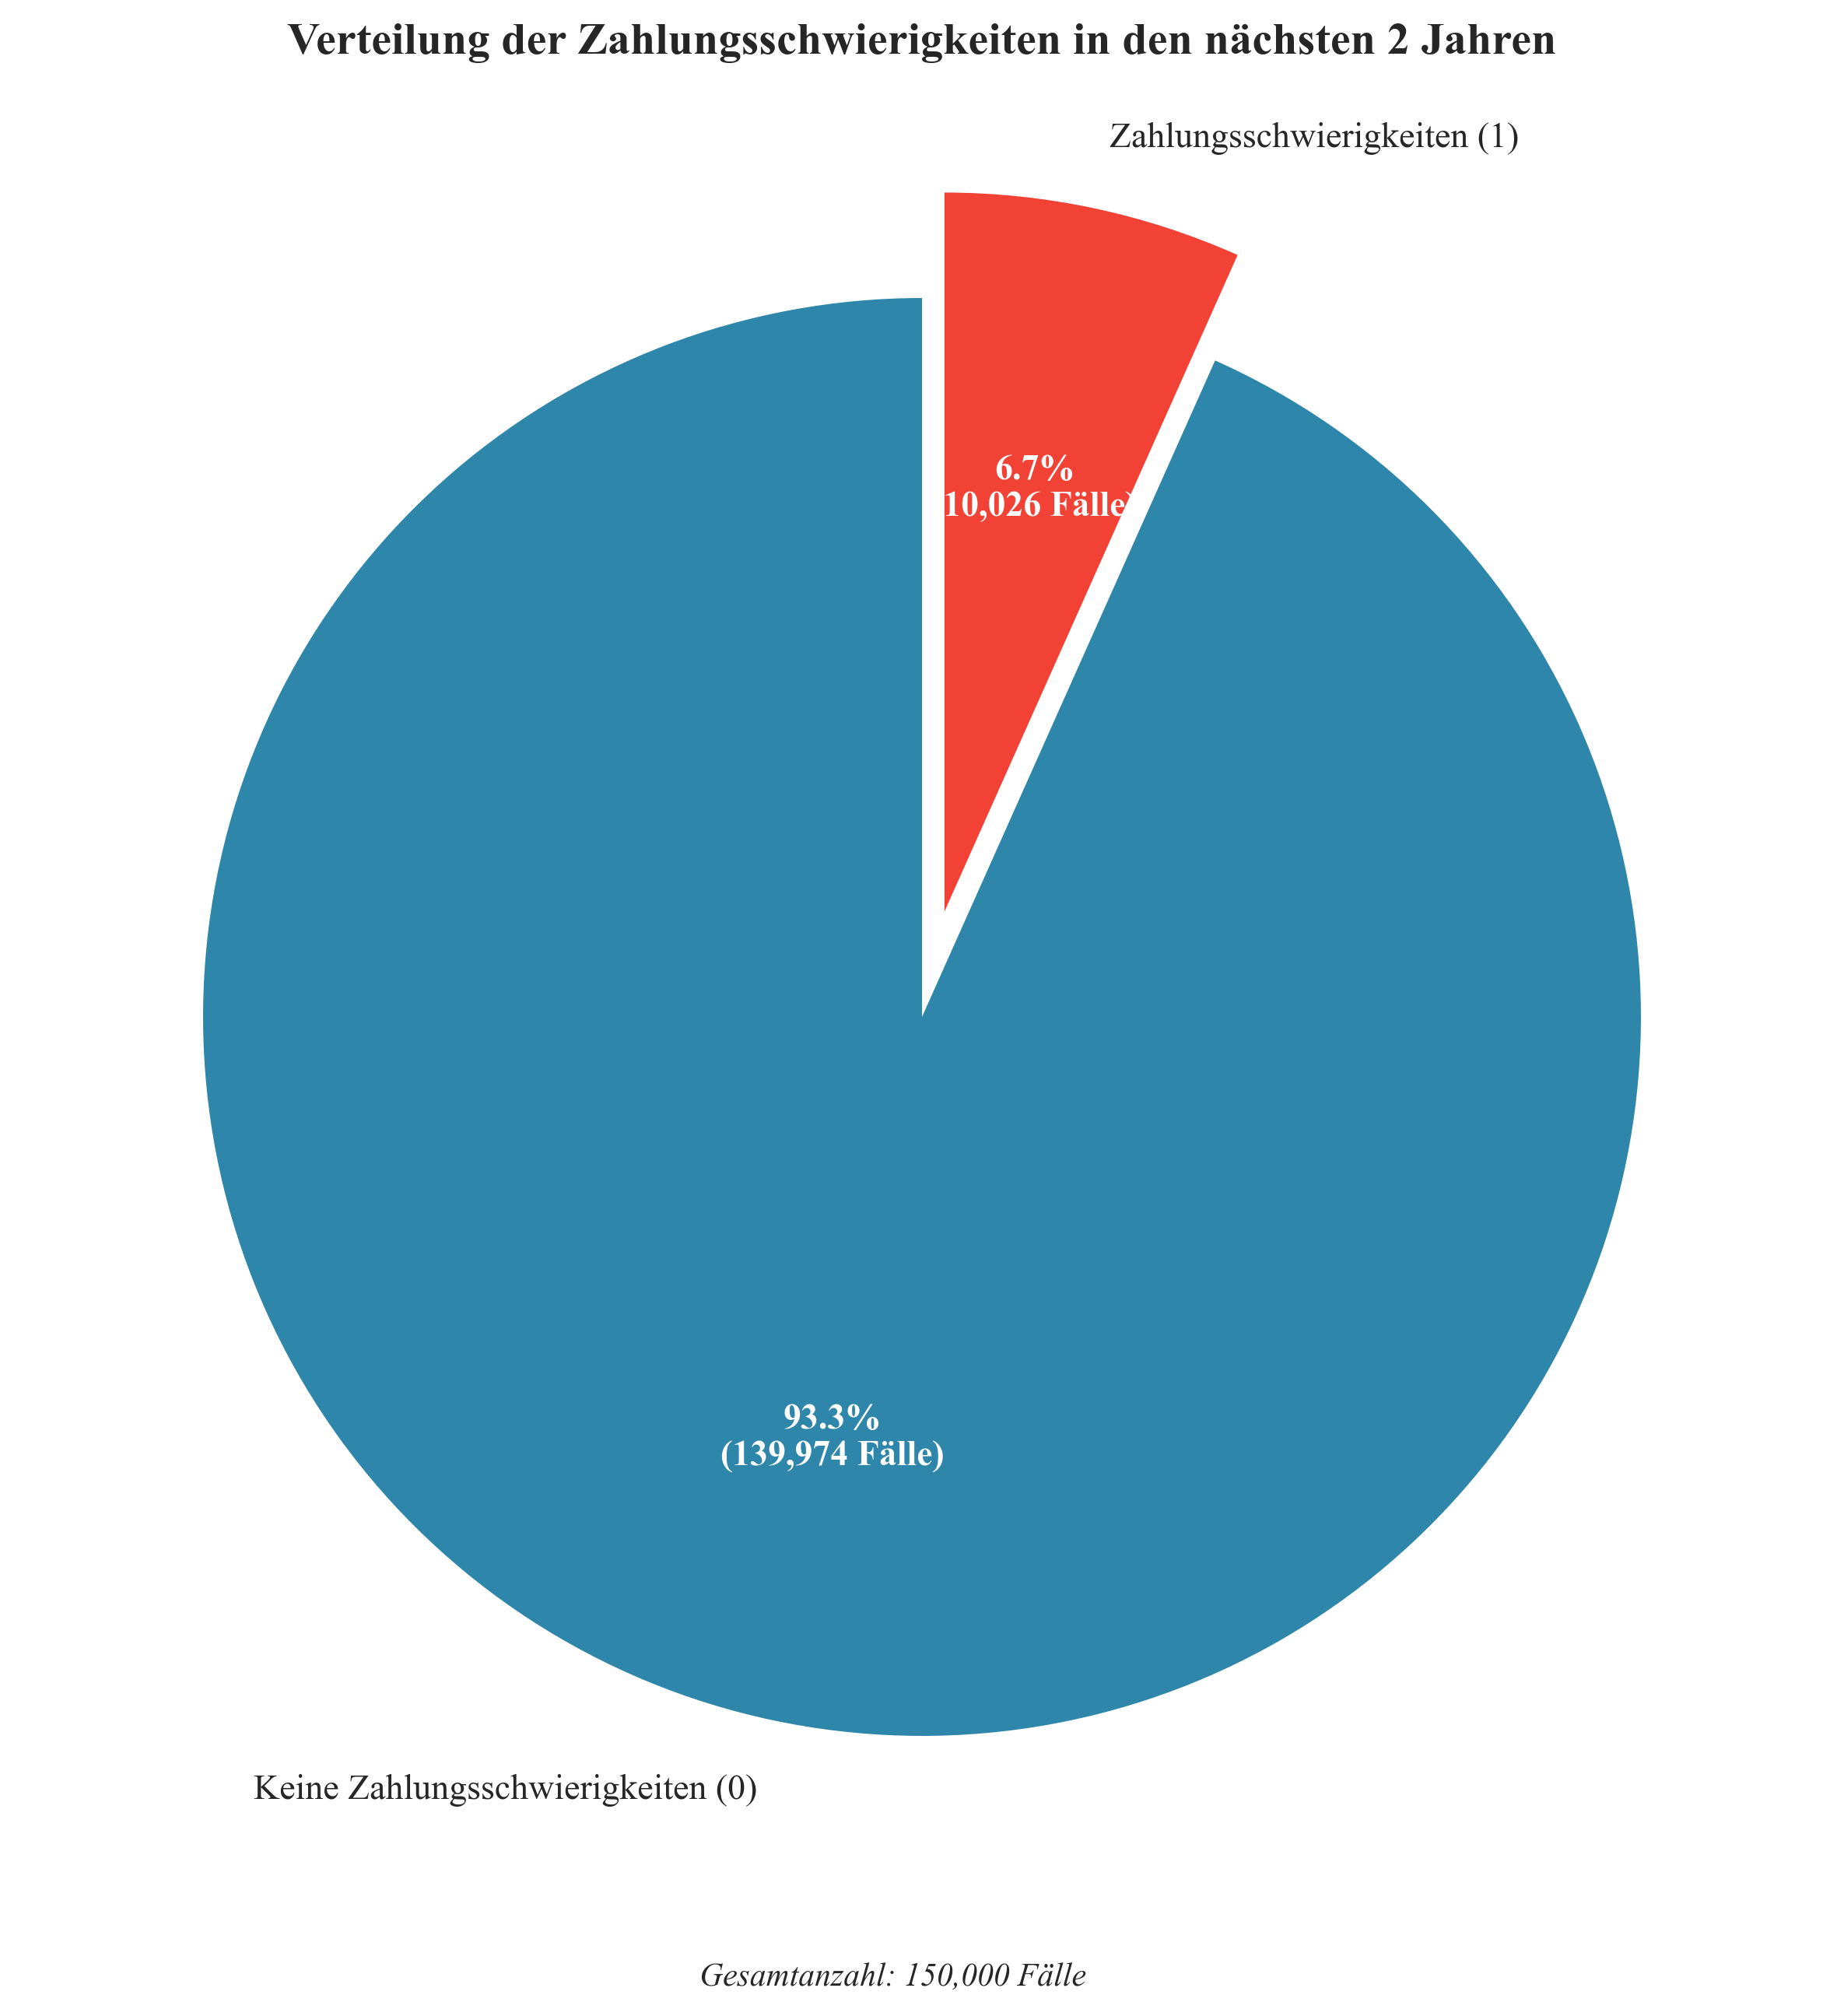

In [53]:
# Visualisierung der Target-Variable
fig, ax = plt.subplots(figsize=(10, 10))

counts = train_data_final['SeriousDlqin2yrs'].value_counts().sort_index()
labels = ['Keine Zahlungsschwierigkeiten (0)', 'Zahlungsschwierigkeiten (1)']
colors = ['#2E86AB', '#F24236']

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct*total/100.0))
        return f'{pct:.1f}%\n({val:,} Fälle)'
    return my_autopct

wedges, texts, autotexts = ax.pie(counts.values, 
                                  labels=labels,
                                  autopct=make_autopct(counts.values),
                                  colors=colors,
                                  explode=(0, 0.15),
                                  shadow=False,
                                  startangle=90,
                                  textprops={'fontsize': 11},
                                  center=(0, 0))

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax.set_title('Verteilung der Zahlungsschwierigkeiten in den nächsten 2 Jahren', 
             fontsize=14, fontweight='bold', pad=20)

total_cases = len(train_data_final)
plt.figtext(0.5, 0.08, f'Gesamtanzahl: {total_cases:,} Fälle', 
            ha='center', fontsize=10, style='italic')
plt.show()

fig.savefig('figs/payment_difficulties_distribution.svg', format='svg', dpi=300, bbox_inches='tight')
fig.savefig('figs/payment_difficulties_distribution.pdf', format='pdf', dpi=300, bbox_inches='tight')

In [54]:
# Ersetze extreme Werte im Trainingsdatensatz
# Wir nutzen die nächsthöchsten Werte (13, 11, 17) als Ersatz

train_data_final.loc[train_data_final['NumberOfTime30-59DaysPastDueNotWorse'] >= 90, 'NumberOfTime30-59DaysPastDueNotWorse'] = 13
train_data_final.loc[train_data_final['NumberOfTime60-89DaysPastDueNotWorse'] >= 90, 'NumberOfTime60-89DaysPastDueNotWorse'] = 11
train_data_final.loc[train_data_final['NumberOfTimes90DaysLate'] >= 90, 'NumberOfTimes90DaysLate'] = 17

print("Unique values in 'NumberOfTime30-59DaysPastDueNotWorse':", np.sort(train_data_final['NumberOfTime30-59DaysPastDueNotWorse'].unique()))
print("Unique values in 'NumberOfTime60-89DaysPastDueNotWorse':", np.sort(train_data_final['NumberOfTime60-89DaysPastDueNotWorse'].unique()))
print("Unique values in 'NumberOfTimes90DaysLate':", np.sort(train_data_final['NumberOfTimes90DaysLate'].unique()))

Unique values in 'NumberOfTime30-59DaysPastDueNotWorse': [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13]
Unique values in 'NumberOfTime60-89DaysPastDueNotWorse': [ 0  1  2  3  4  5  6  7  8  9 11]
Unique values in 'NumberOfTimes90DaysLate': [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 17]


In [55]:
# Ersetze extreme Werte im Testdatensatz
# Wir nutzen die nächsthöchsten Werte (19, 9, 18) als Ersatz

test_data_final.loc[test_data_final['NumberOfTime30-59DaysPastDueNotWorse'] >= 90, 'NumberOfTime30-59DaysPastDueNotWorse'] = 19
test_data_final.loc[test_data_final['NumberOfTime60-89DaysPastDueNotWorse'] >= 90, 'NumberOfTime60-89DaysPastDueNotWorse'] = 9
test_data_final.loc[test_data_final['NumberOfTimes90DaysLate'] >= 90, 'NumberOfTimes90DaysLate'] = 18

print("Unique values in 'NumberOfTime30-59DaysPastDueNotWorse':", np.sort(test_data_final['NumberOfTime30-59DaysPastDueNotWorse'].unique()))
print("Unique values in 'NumberOfTime60-89DaysPastDueNotWorse':", np.sort(test_data_final['NumberOfTime60-89DaysPastDueNotWorse'].unique()))
print("Unique values in 'NumberOfTimes90DaysLate':", np.sort(test_data_final['NumberOfTimes90DaysLate'].unique()))

Unique values in 'NumberOfTime30-59DaysPastDueNotWorse': [ 0  1  2  3  4  5  6  7  8  9 10 11 12 19]
Unique values in 'NumberOfTime60-89DaysPastDueNotWorse': [0 1 2 3 4 5 6 7 8 9]
Unique values in 'NumberOfTimes90DaysLate': [ 0  1  2  3  4  5  6  7  8  9 10 11 12 16 17 18]


In [56]:
# Entferne Datensätze mit extrem hohen DebtRatio-Werten, anhand der 95. Perzentile
# Entferne Datensätze, wo die Zielvariable 'SeriousDlqin2yrs' gleich dem 'MonthlyIncome' ist

train_data_final = train_data_final[-((train_data_final['DebtRatio'] > train_data_final['DebtRatio'].quantile(0.95)) &
                                      (train_data_final['SeriousDlqin2yrs'] == train_data_final['MonthlyIncome']))]

In [57]:
# Entferne Datensätze mit extrem hohen RevolvingUtilizationOfUnsecuredLines-Werten

train_data_final = train_data_final[train_data_final['RevolvingUtilizationOfUnsecuredLines'] < 13]

In [58]:
# Analyse fehlender Werte
def MissingHandler(df):
    DataMissing = df.isnull().sum()*100 / len(df)
    DataMissingByCol = pd.DataFrame({'DataMissing Percentage': DataMissing})
    DataMissingByCol.sort_values(by='DataMissing Percentage', ascending=False, inplace=True)
    return DataMissingByCol[DataMissingByCol['DataMissing Percentage'] > 0]

print("Fehlende Werte Trainingsdaten:")
print(MissingHandler(train_data_final))
print("\nFehlende Werte Testdaten:")
print(MissingHandler(test_data_final))

Fehlende Werte Trainingsdaten:
                    DataMissing Percentage
MonthlyIncome                    19.850633
NumberOfDependents                2.617261

Fehlende Werte Testdaten:
                    DataMissing Percentage
MonthlyIncome                    19.805326
NumberOfDependents                2.587116


In [59]:
# Imputation fehlender Werte
train_data_final['MonthlyIncome'].fillna(train_data_final['MonthlyIncome'].median(), inplace=True)
train_data_final['NumberOfDependents'].fillna(0, inplace=True)

test_data_final['MonthlyIncome'].fillna(test_data_final['MonthlyIncome'].median(), inplace=True)
test_data_final['NumberOfDependents'].fillna(0, inplace=True)

print(MissingHandler(train_data_final))
print(MissingHandler(test_data_final))

Empty DataFrame
Columns: [DataMissing Percentage]
Index: []
Empty DataFrame
Columns: [DataMissing Percentage]
Index: []


In [60]:
# Finale Datendimensionen
print(f"Trainingsdaten: {train_data_final.shape}")
print(f"Testdaten: {test_data_final.shape}")

Trainingsdaten: (149431, 11)
Testdaten: (101503, 10)


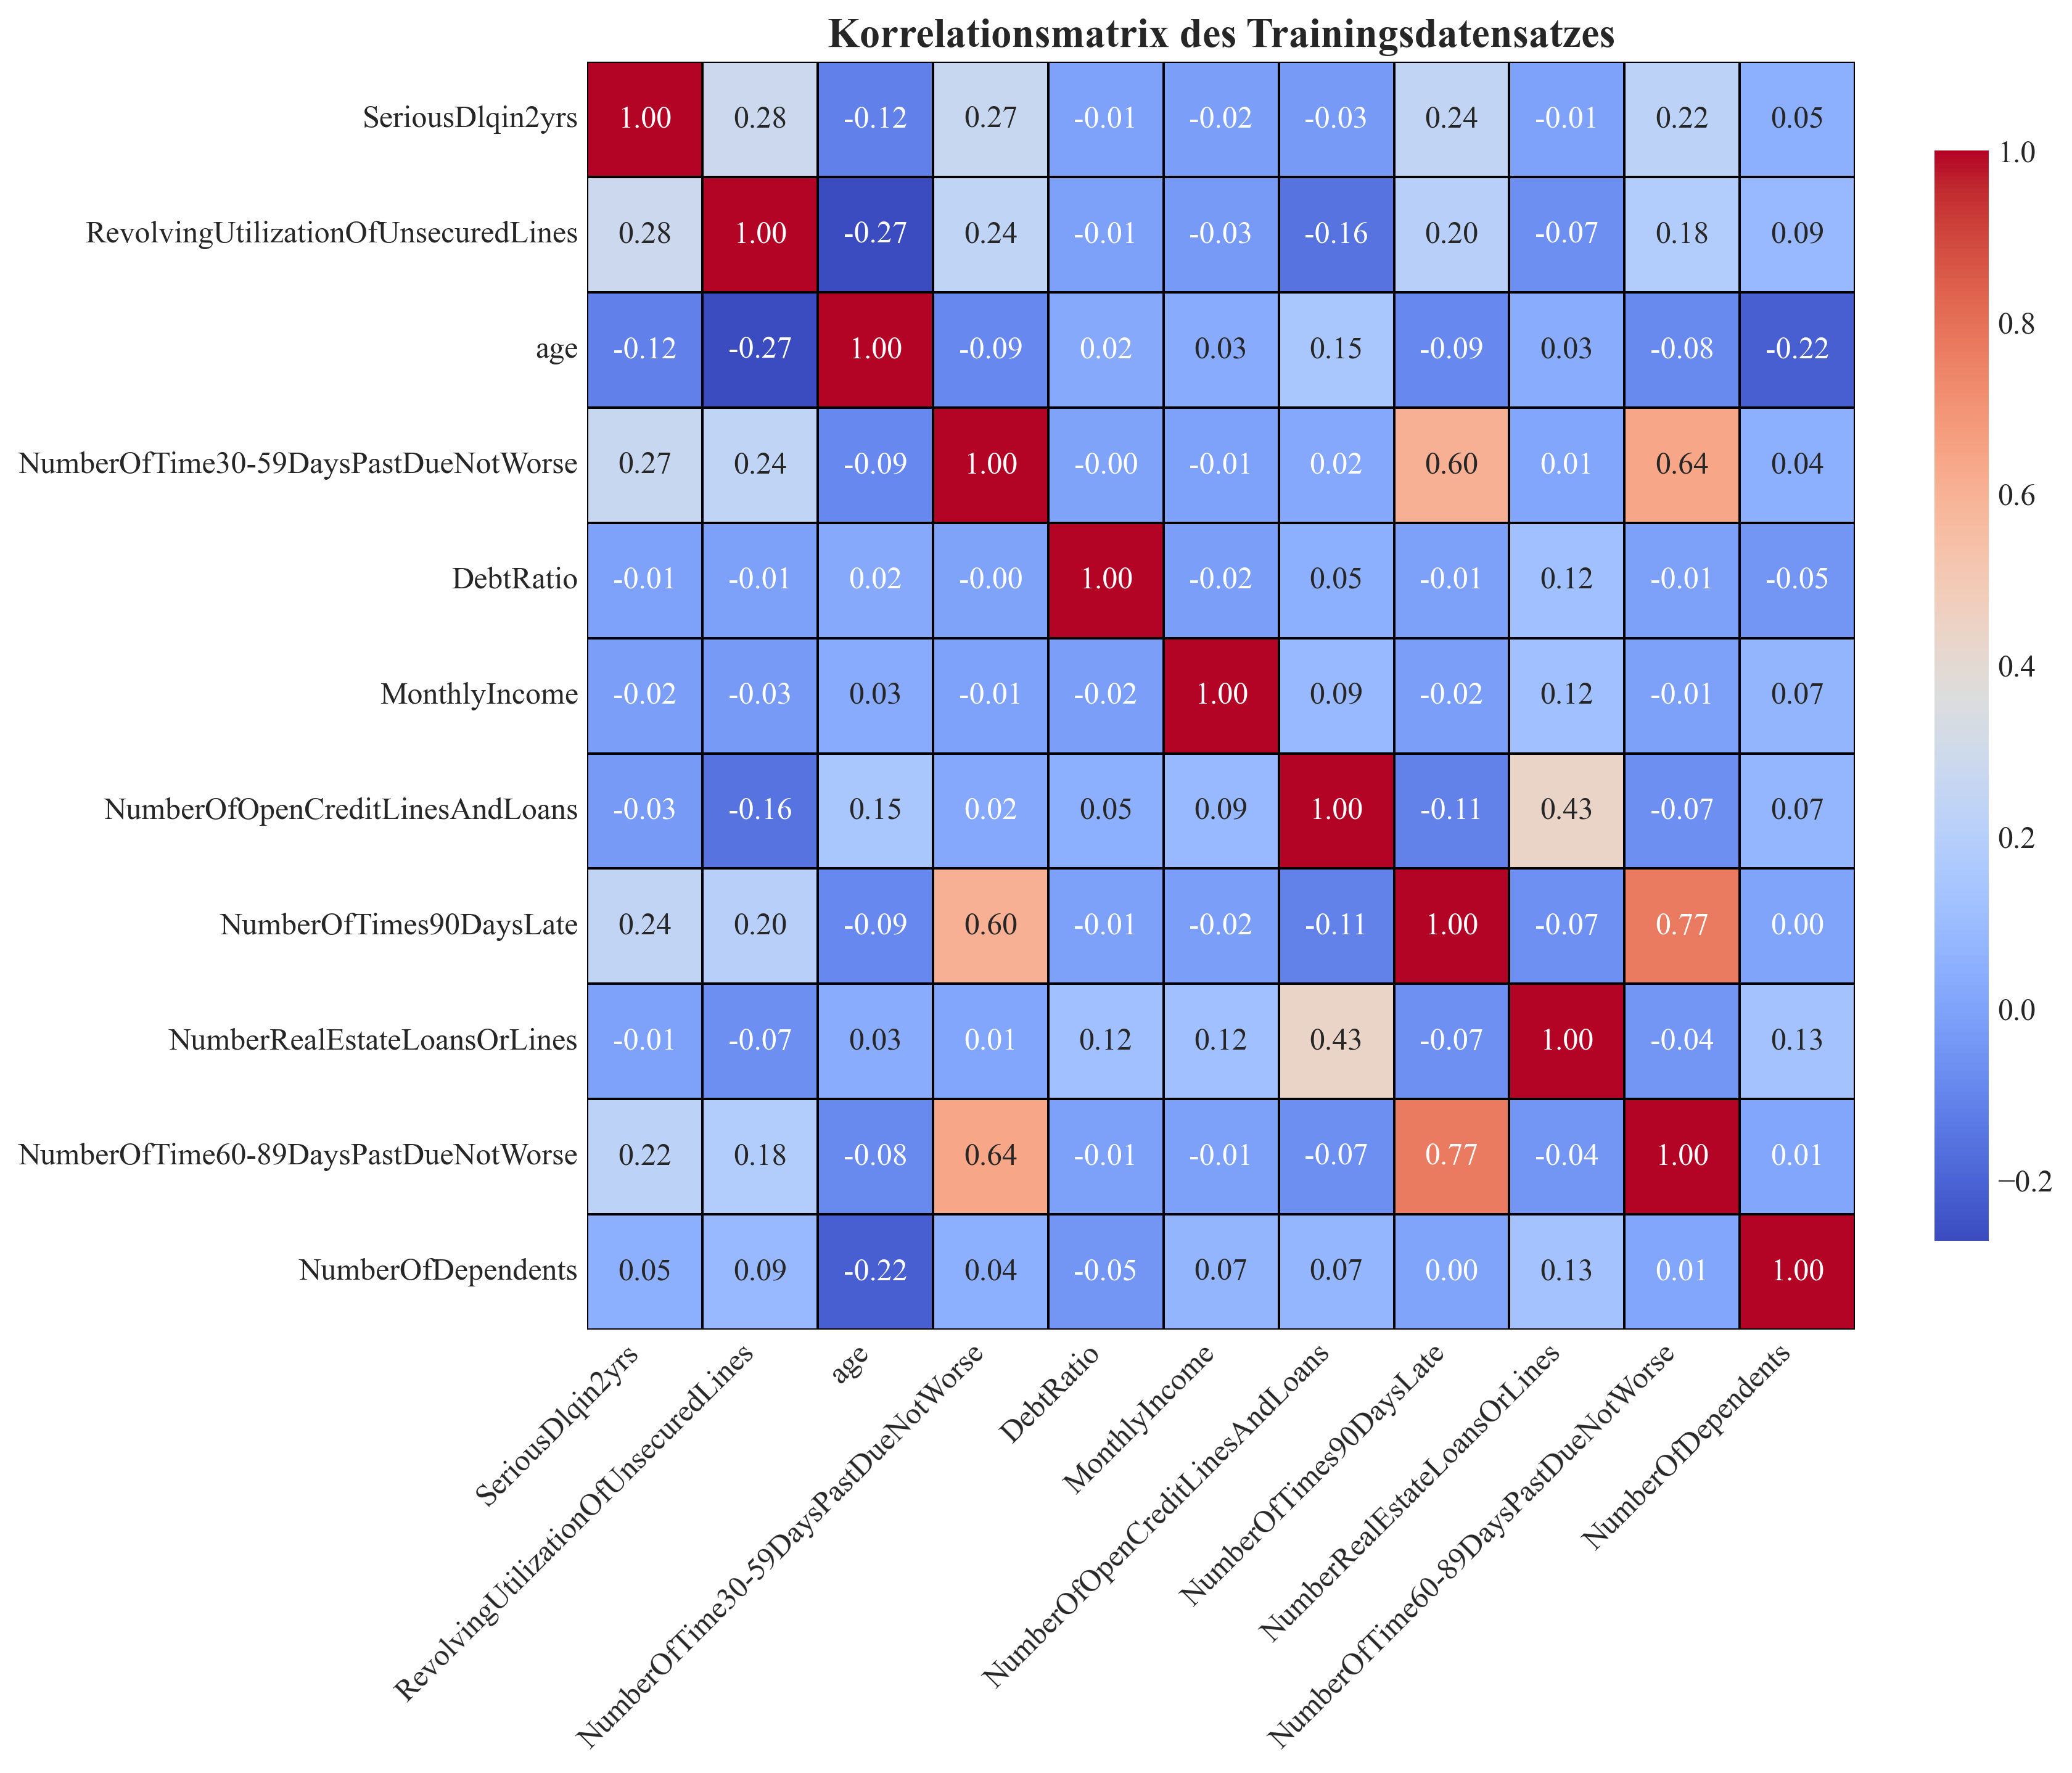

Höchste Korrelationen zur Zielvariable 'SeriousDlqin2yrs':
SeriousDlqin2yrs                        1.000000
RevolvingUtilizationOfUnsecuredLines    0.281472
NumberOfTime30-59DaysPastDueNotWorse    0.265596
NumberOfTimes90DaysLate                 0.242439
NumberOfTime60-89DaysPastDueNotWorse    0.220657
Name: SeriousDlqin2yrs, dtype: float64


In [61]:
# Korrelationsmatrix
plt.figure(figsize=(12, 10))
correlation_matrix = train_data_final.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, 
            cbar_kws={"shrink": .8}, linewidths=0.5, linecolor='black')
plt.title('Korrelationsmatrix des Trainingsdatensatzes', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Höchste Korrelationen zur Zielvariable 'SeriousDlqin2yrs':")
print(correlation_matrix['SeriousDlqin2yrs'].sort_values(ascending=False).head(5))

In [62]:
# Feature Engineering
def add_features(df):
    df['MonthlyIncomePerPerson'] = df['MonthlyIncome'] / (df['NumberOfDependents'] + 1)
    df['MonthlyIncomePerPerson'].fillna(df['MonthlyIncomePerPerson'].median(), inplace=True)
    df['MonthlyDebt'] = df['DebtRatio'] * df['MonthlyIncome']
    df['MonthlyDebt'].fillna(df['MonthlyDebt'].median(), inplace=True)
    df['isRetired'] = (np.where(df['age'] >= 65, 1, 0)).astype(int)
    df['RevolvingLines'] = df['NumberOfOpenCreditLinesAndLoans'] - df['NumberRealEstateLoansOrLines']
    df['hasRevolvingLines'] = np.where(df['RevolvingLines'] > 0, 1, 0).astype(int)
    df['hasMultipleRealEstates'] = np.where(df['NumberRealEstateLoansOrLines'] > 1, 1, 0).astype(int)
    #df['incomeDivByThousand'] = df['MonthlyIncome'] / 1000
    return df

train_data_final = add_features(train_data_final)
test_data_final = add_features(test_data_final)

print(f"Trainingsdaten: {train_data_final.shape}")
print(f"Testdaten: {test_data_final.shape}")

Trainingsdaten: (149431, 17)
Testdaten: (101503, 16)


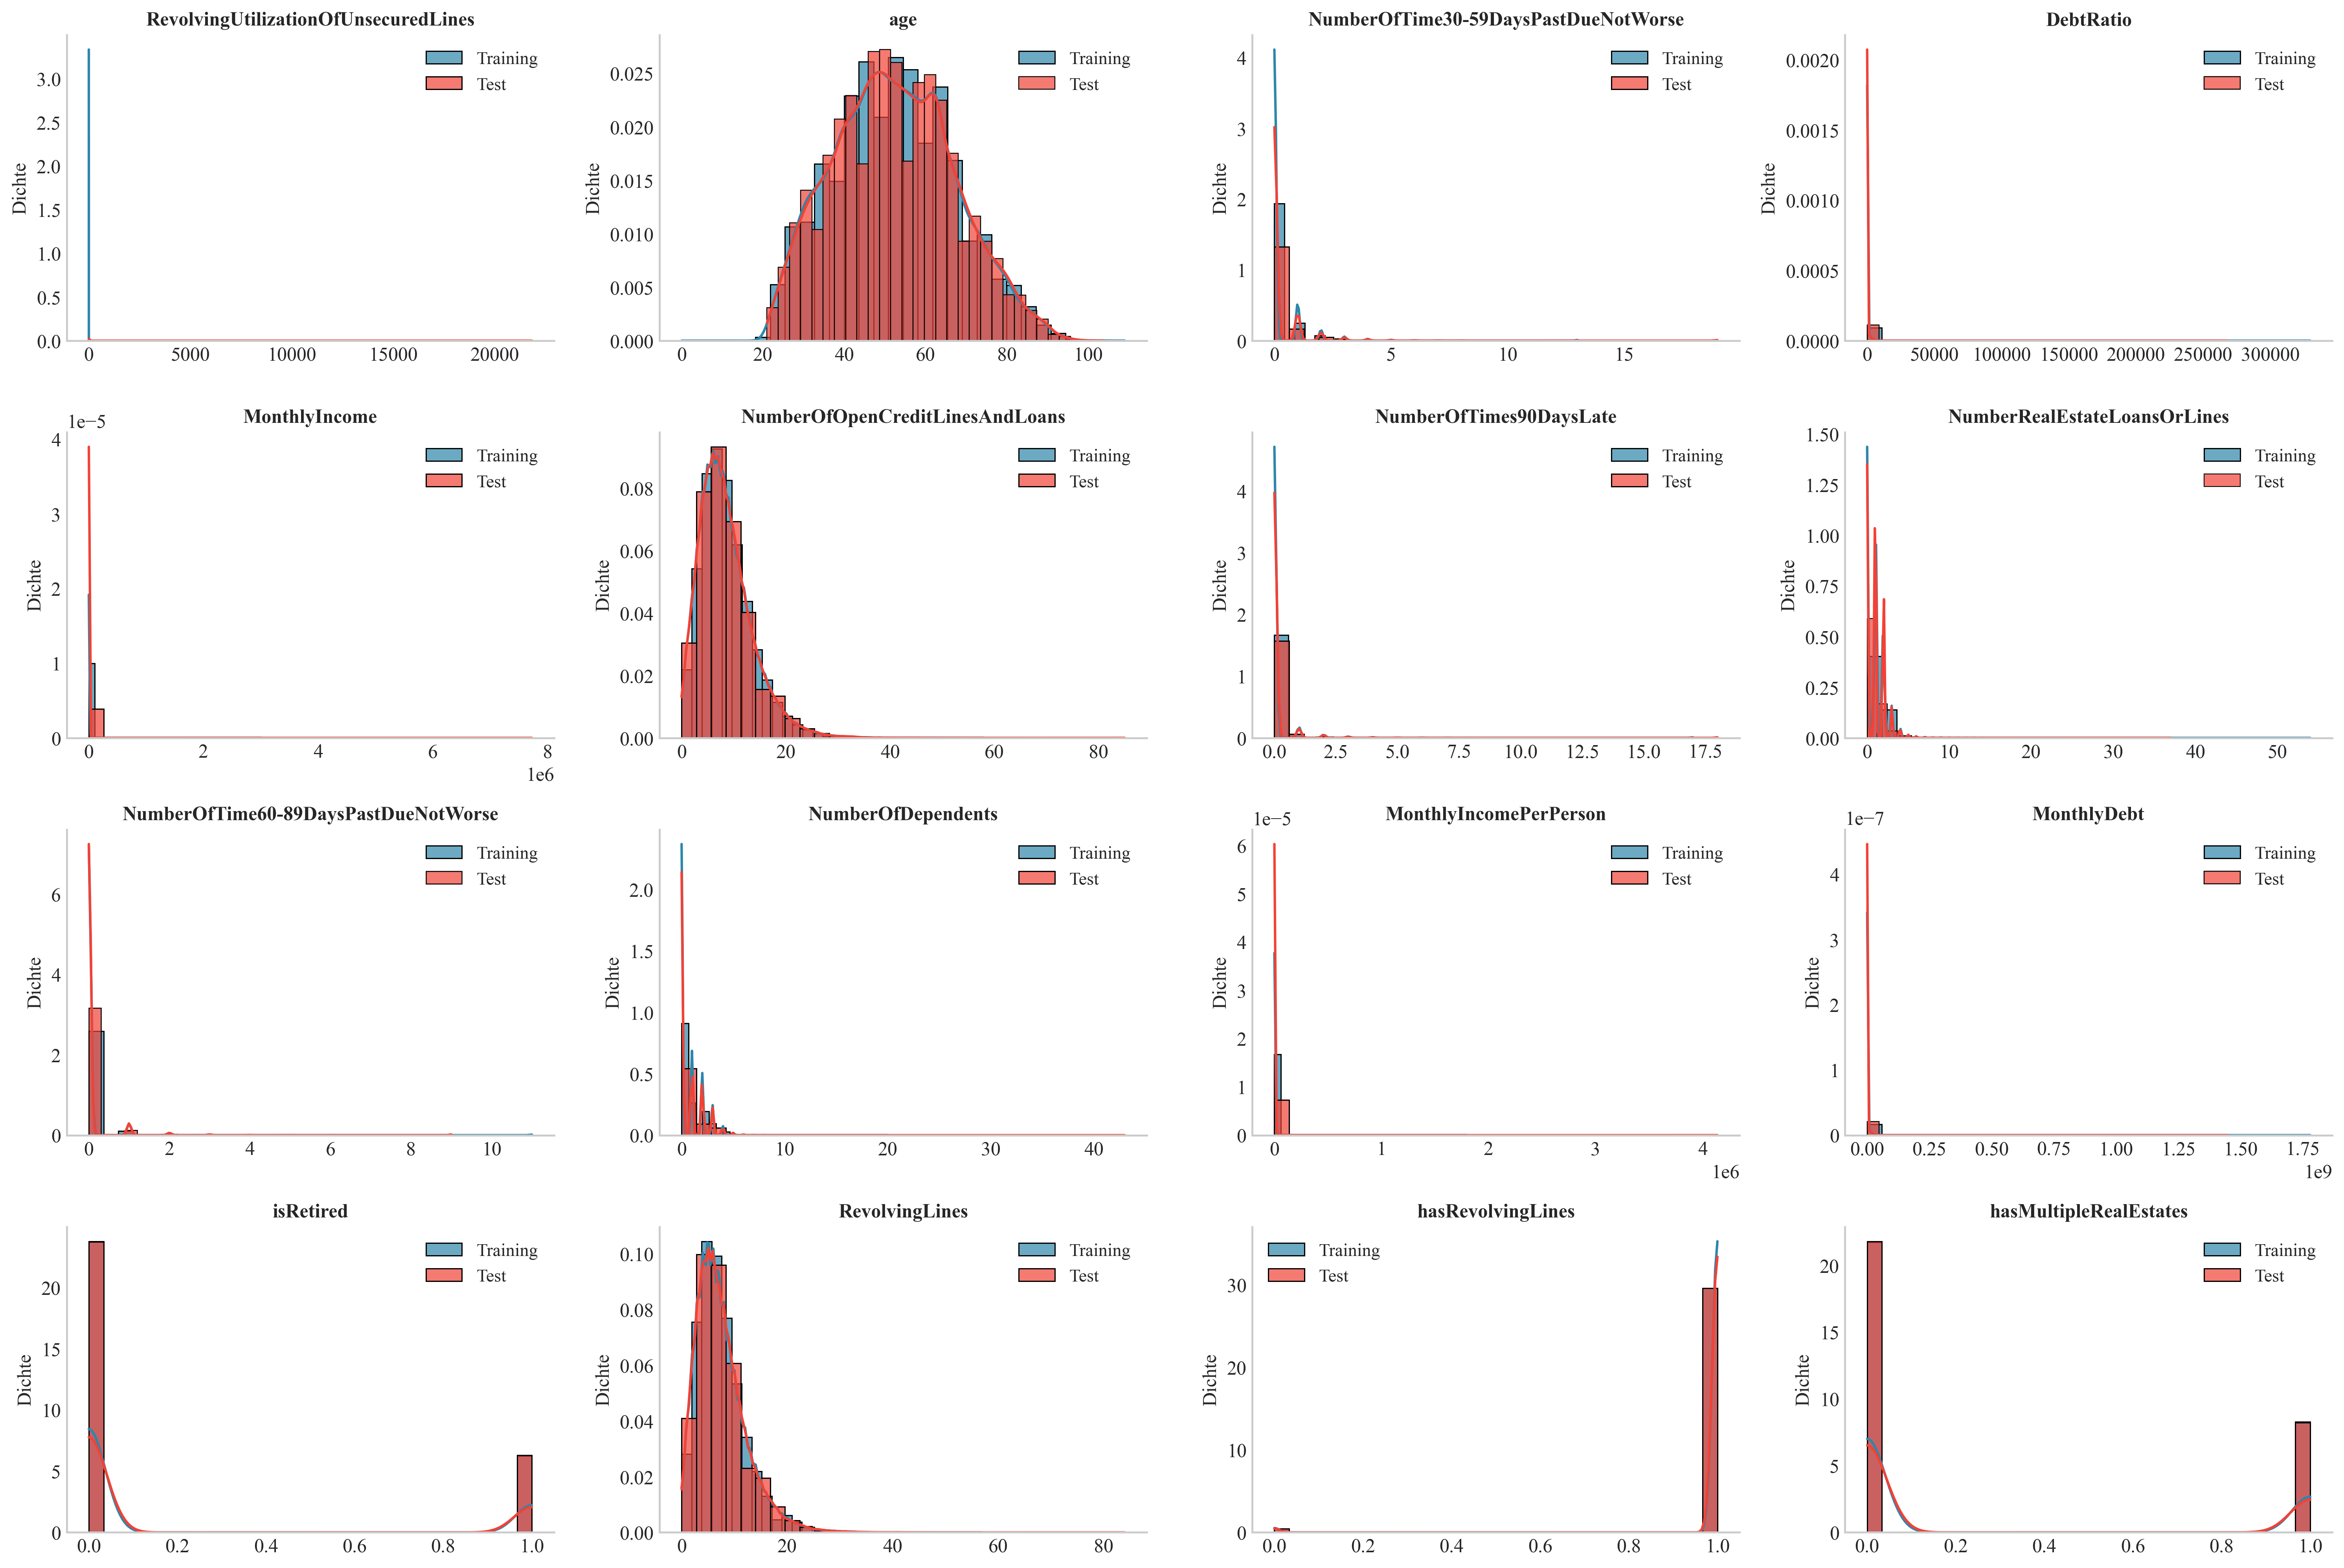

In [63]:
# Verteilungsvergleich aller Features
features = list(train_data_final.columns.drop(['SeriousDlqin2yrs']))

fig = plt.figure(figsize=(20, 20))
for feature, i in zip(features, range(len(features))):
    axes = fig.add_subplot(6, 4, i + 1)
    
    sns.histplot(train_data_final[feature], kde=True, ax=axes, color='#2E86AB', 
                 bins=30, alpha=0.7, label='Training', stat='density')
    sns.histplot(test_data_final[feature], kde=True, ax=axes, color='#F24236', 
                 bins=30, alpha=0.7, label='Test', stat='density')
    
    axes.set_title(feature, fontsize=12, fontweight='bold')
    axes.set_xlabel('')
    axes.set_ylabel('Dichte')
    axes.legend()
    axes.grid(False)
    
plt.tight_layout()
plt.show()

In [64]:
# Analyse der Schiefe (Skewness)
def SkewMeasure(df):
    nonObjectColList = df.dtypes[df.dtypes != 'object'].index
    skewM = df[nonObjectColList].apply(lambda x: stats.skew(x.dropna().sort_values(ascending=False)))
    skewM = pd.DataFrame({'skewness': skewM})
    return skewM[abs(skewM['skewness']) > 0.5].sort_values(by='skewness', ascending=False)

skewness_train = SkewMeasure(train_data_final)
print("Skewness der Features im Trainingsdatensatz:")
print(skewness_train)

print("\n")

skewness_test = SkewMeasure(test_data_final)
print("Skewness der Features im Testdatensatz:")
print(skewness_test)

Skewness der Features im Trainingsdatensatz:
                                        skewness
MonthlyIncome                         127.043051
MonthlyIncomePerPerson                105.747791
MonthlyDebt                            99.323744
DebtRatio                              98.040325
NumberOfTimes90DaysLate                14.954749
NumberOfTime60-89DaysPastDueNotWorse   14.156184
NumberOfTime30-59DaysPastDueNotWorse    7.456035
NumberRealEstateLoansOrLines            3.491554
SeriousDlqin2yrs                        3.464311
RevolvingUtilizationOfUnsecuredLines    2.163945
NumberOfDependents                      1.626209
isRetired                               1.437542
RevolvingLines                          1.356071
NumberOfOpenCreditLinesAndLoans         1.215508
hasMultipleRealEstates                  1.003434
hasRevolvingLines                      -8.029835


Skewness der Features im Testdatensatz:
                                        skewness
MonthlyIncome                  

In [65]:
# Nutze Box Cox Transformation für Features mit hoher Skewness im Trainingsdatensatz und Testdatensatz mit Lambda = 0.15
# Lasse Zielvariable 'SeriousDlqin2yrs' unverändert, da sie binär ist

for feature in skewness_train.index:
    train_data_final[feature] = special.boxcox1p(train_data_final[feature], 0.15) if feature != 'SeriousDlqin2yrs' else train_data_final[feature]

for feature in skewness_test.index:
    test_data_final[feature] = special.boxcox1p(test_data_final[feature], 0.15) if feature != 'SeriousDlqin2yrs' else test_data_final[feature]

# Verifikation der Transformation
skewness_train_after = SkewMeasure(train_data_final)
print("Skewness der Features im Trainingsdatensatz nach Box Cox Transformation:")
print(skewness_train_after)

print("\n")

skewness_test_after = SkewMeasure(test_data_final)
print("Skewness der Features im Testdatensatz nach Box Cox Transformation:")
print(skewness_test_after)

Skewness der Features im Trainingsdatensatz nach Box Cox Transformation:
                                      skewness
NumberOfTime60-89DaysPastDueNotWorse  6.714410
NumberOfTimes90DaysLate               6.702142
SeriousDlqin2yrs                      3.464311
NumberOfTime30-59DaysPastDueNotWorse  3.043815
DebtRatio                             1.962198
MonthlyDebt                           1.804709
isRetired                             1.437542
hasMultipleRealEstates                1.003434
NumberOfDependents                    0.949621
RevolvingUtilizationOfUnsecuredLines  0.886177
MonthlyIncomePerPerson               -1.569139
MonthlyIncome                        -2.153922
hasRevolvingLines                    -8.029835


Skewness der Features im Testdatensatz nach Box Cox Transformation:
                                       skewness
RevolvingUtilizationOfUnsecuredLines  21.124434
NumberOfTimes90DaysLate                6.896935
NumberOfTime60-89DaysPastDueNotWorse   6.431292
NumberO

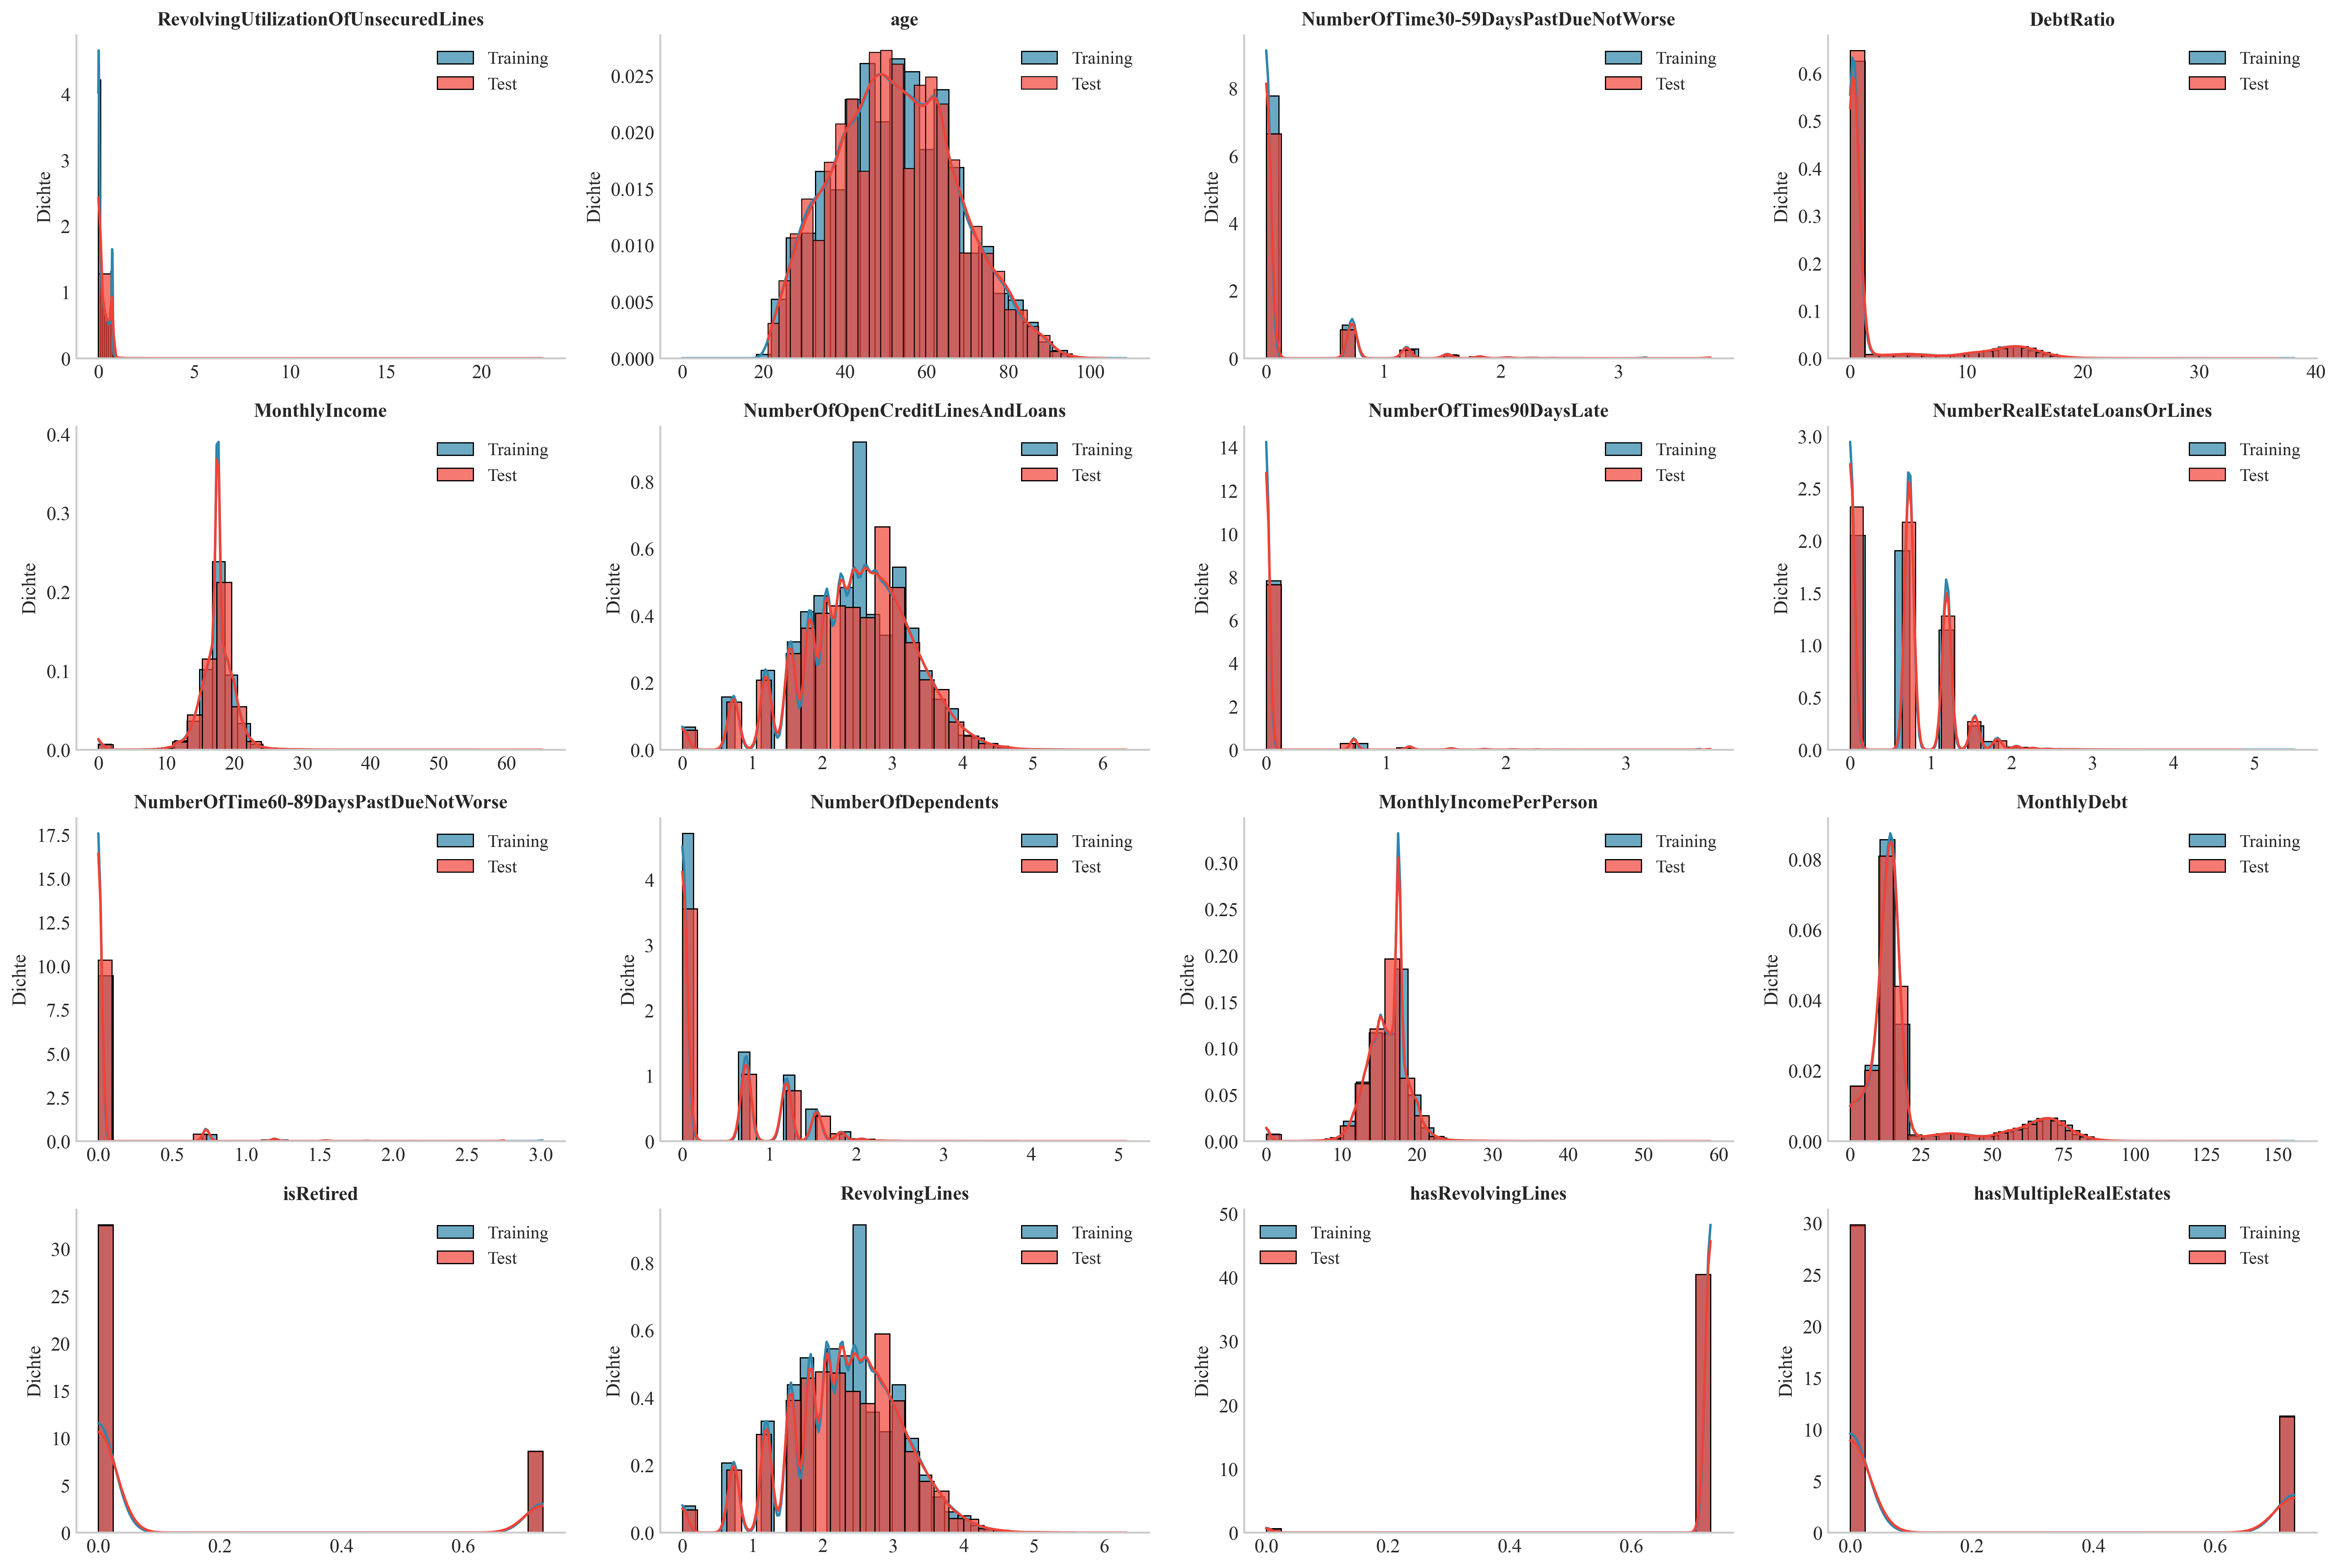

In [66]:
# Verteilungen nach Box-Cox Transformation
features = list(train_data_final.columns.drop(['SeriousDlqin2yrs']))

fig = plt.figure(figsize=(20, 20))
for feature, i in zip(features, range(len(features))):
    axes = fig.add_subplot(6, 4, i + 1)
    
    sns.histplot(train_data_final[feature], kde=True, ax=axes, color='#2E86AB', 
                 bins=30, alpha=0.7, label='Training', stat='density')
    sns.histplot(test_data_final[feature], kde=True, ax=axes, color='#F24236', 
                 bins=30, alpha=0.7, label='Test', stat='density')
    
    axes.set_title(feature, fontsize=12, fontweight='bold')
    axes.set_xlabel('')
    axes.set_ylabel('Dichte')
    axes.legend()
    axes.grid(False)
    
plt.tight_layout()
plt.show()

In [67]:
# Modelltraining und Evaluation
x_train, x_test, y_train, y_test = train_test_split(train_data_final.drop('SeriousDlqin2yrs', axis=1), 
                                                    train_data_final['SeriousDlqin2yrs'], 
                                                    test_size=0.3, 
                                                    random_state=42, 
                                                    stratify=train_data_final['SeriousDlqin2yrs'])

# LightGBM

"""lgb_attributes = lgb.LGBMClassifier(objective='binary', n_jobs=-1, importance_type='gain', random_state=42)

lgb_parameters = {
    'max_depth': [2,3,4,5],
    'learning_rate': [0.05, 0.1, 0.125, 0.15],
    'colsample_bytree': [0.2, 0.4, 0.6, 0.8, 1.0],
    'n_estimators': [400, 500, 600, 700, 800, 900],
    'min_split_gain': [0.15, 0.2, 0.25, 0.3, 0.35],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [6, 7, 8, 9, 10],
    'scale_pos_weight': [10, 15, 20],
    'min_data_in_leaf': [100, 200, 300, 400, 500, 600, 700, 800, 900],
    'num_leaves': [20, 30, 40, 50, 60, 70, 80, 90, 100]
}

warnings.filterwarnings("ignore", category=UserWarning, module='lightgbm')

lgb_model = RandomizedSearchCV(estimator=lgb_attributes,
                               param_distributions=lgb_parameters,
                               cv = 5,
                               scoring='roc_auc',
                               random_state=42,
                               n_jobs=-1)

lgb_model.fit(x_train, y_train, feature_name=x_train.columns.tolist())
best_lgb_estimator = lgb_model.best_estimator_
print("Beste Parameter für LightGBM:")
print(lgb_model.best_params_)"""


# Beste Parameter für LightGBM nach Random Search:
# {'subsample': 0.9, 'scale_pos_weight': 20, 'num_leaves': 70, 'n_estimators': 400, 'min_split_gain': 0.15, 'min_data_in_leaf': 300, 'min_child_weight': 7, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.6}

best_lgb_estimator = lgb.LGBMClassifier(objective='binary', n_jobs=-1, importance_type='gain', random_state=42,
                                         subsample=0.9, scale_pos_weight=20, num_leaves=70, n_estimators=400,
                                         min_split_gain=0.15, min_data_in_leaf=300, min_child_weight=7,
                                         max_depth=5, learning_rate=0.05, colsample_bytree=0.6)
best_lgb_estimator.fit(x_train, y_train, feature_name=x_train.columns.tolist())

[LightGBM] [Warning] min_data_in_leaf is set=300, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=300
[LightGBM] [Warning] min_data_in_leaf is set=300, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=300
[LightGBM] [Info] Number of positive: 7006, number of negative: 97595
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002458 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1533
[LightGBM] [Info] Number of data points in the train set: 104601, number of used features: 16
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.066978 -> initscore=-2.634059
[LightGBM] [Info] Start training from score -2.634059
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

,boosting_type,'gbdt'
,num_leaves,70
,max_depth,5
,learning_rate,0.05
,n_estimators,400
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.15
,min_child_weight,7
,min_child_samples,20


[LightGBM] [Warning] min_data_in_leaf is set=300, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=300
[LightGBM] [Warning] min_data_in_leaf is set=300, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=300


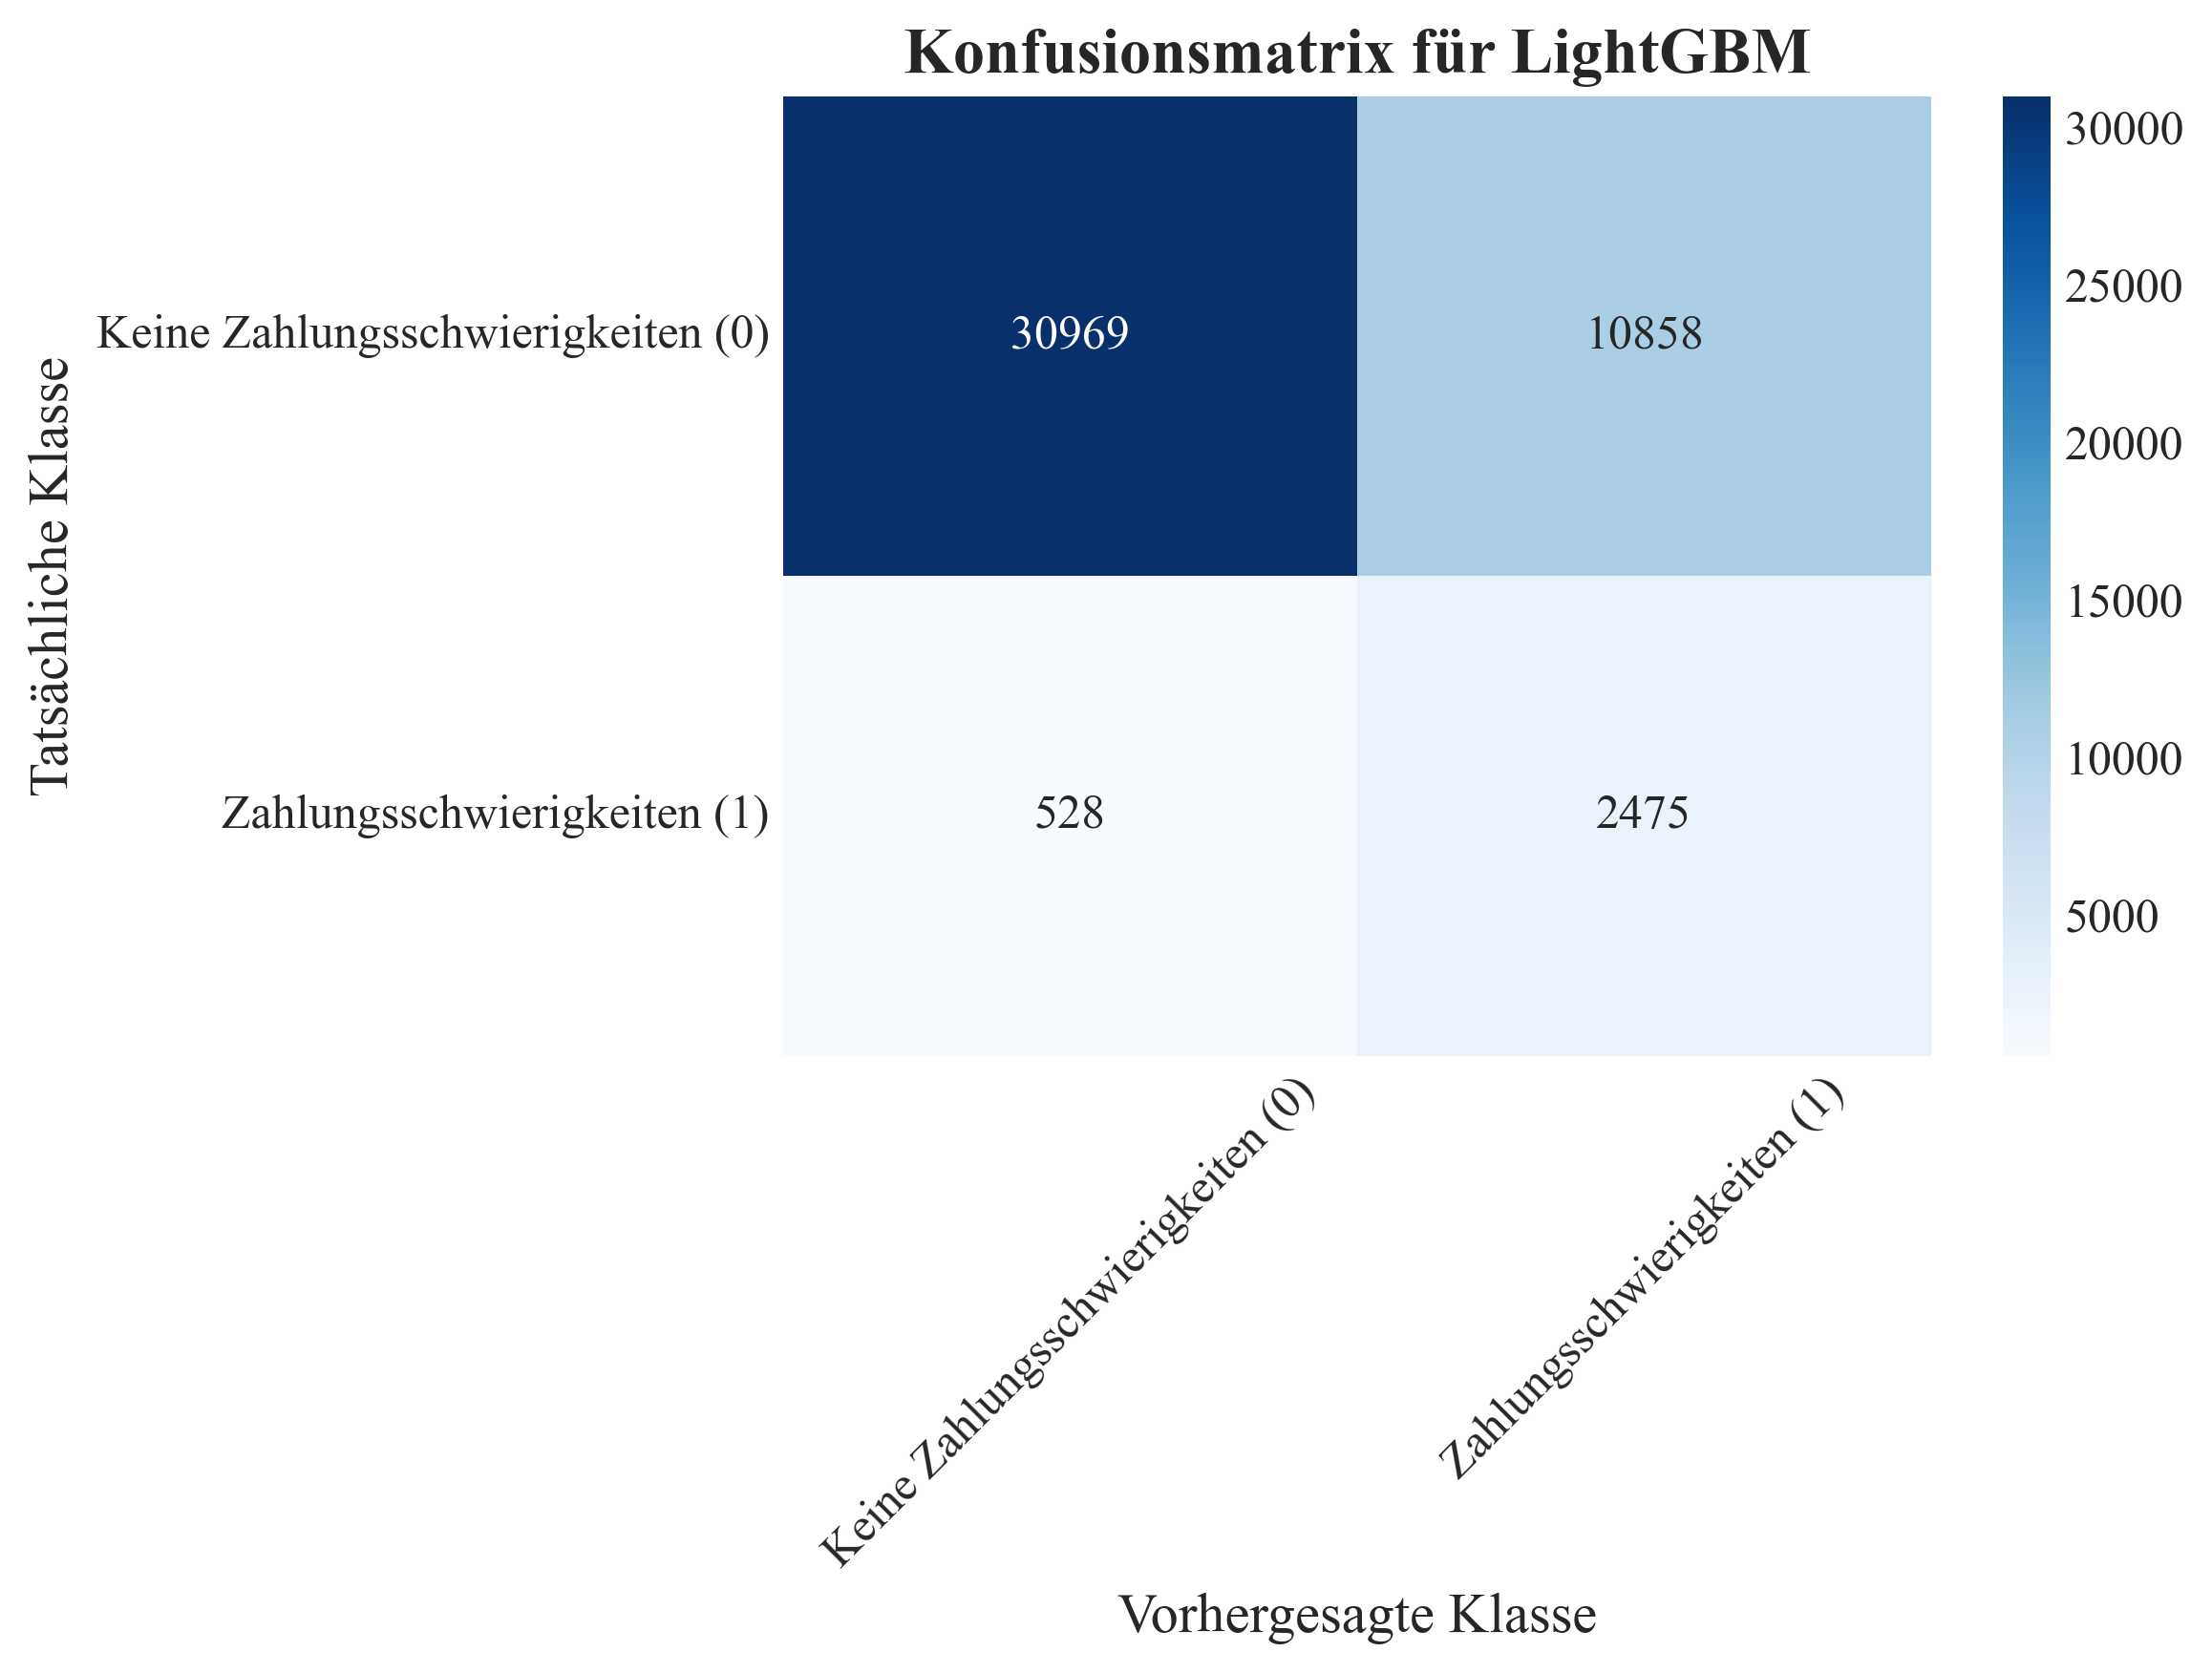

[LightGBM] [Warning] min_data_in_leaf is set=300, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=300
[LightGBM] [Warning] min_data_in_leaf is set=300, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=300
[LightGBM] [Warning] min_data_in_leaf is set=300, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=300
[LightGBM] [Warning] min_data_in_leaf is set=300, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=300
[LightGBM] [Warning] min_data_in_leaf is set=300, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=300
LightGBM Metriken:
      Model  Accuracy Train  Accuracy Test  ROC AUC Train  ROC AUC Test  \
0  LightGBM        0.752526       0.746018       0.892489      0.864379   

   Precision Train  Precision Test  Recall Train  Recall Test  F1 Score Train  \
0         0.195798         0.18563      0.867257     0.824176         0.31947   

   F1 Score Test  
0       0.303012  
Gesamtanz

In [68]:
# Modell-Evaluation
y_pred_lgb = best_lgb_estimator.predict(x_test)
y_pred_proba_lgb = best_lgb_estimator.predict_proba(x_test)[:, 1]

# Konfusionsmatrix
conf_matrix_lgb = confusion_matrix(y_test, y_pred_lgb)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_matrix_lgb, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Keine Zahlungsschwierigkeiten (0)', 'Zahlungsschwierigkeiten (1)'],
            yticklabels=['Keine Zahlungsschwierigkeiten (0)', 'Zahlungsschwierigkeiten (1)'],
            ax=ax)
ax.set_title('Konfusionsmatrix für LightGBM', fontsize=16, fontweight='bold')
ax.set_xlabel('Vorhergesagte Klasse', fontsize=14)
ax.set_ylabel('Tatsächliche Klasse', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

fig.savefig('figs/confusion_matrix_lightgbm.svg', format='svg', dpi=300, bbox_inches='tight')
fig.savefig('figs/confusion_matrix_lightgbm.pdf', format='pdf', dpi=300, bbox_inches='tight')

# Performance-Metriken
def compute_accuracy_manually(y_true, y_pred):
    return np.mean(y_true == y_pred)
def compute_roc_auc(y_true, y_pred_proba):
    return roc_auc_score(y_true, y_pred_proba)
def compute_precision_manually(y_true, y_pred):
    true_positive = np.sum((y_true == 1) & (y_pred == 1))
    false_positive = np.sum((y_true == 0) & (y_pred == 1))
    return true_positive / (true_positive + false_positive) if (true_positive + false_positive) > 0 else 0
def compute_recall_manually(y_true, y_pred):
    true_positive = np.sum((y_true == 1) & (y_pred == 1))
    false_negative = np.sum((y_true == 1) & (y_pred == 0))
    return true_positive / (true_positive + false_negative) if (true_positive + false_negative) > 0 else 0
def compute_f1_score_manually(y_true, y_pred):
    precision = compute_precision_manually(y_true, y_pred)
    recall = compute_recall_manually(y_true, y_pred)
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0


LGBMMetrics = pd.DataFrame({
    'Model': 'LightGBM',
    'Accuracy Train': [compute_accuracy_manually(y_train, best_lgb_estimator.predict(x_train))],
    'Accuracy Test': [compute_accuracy_manually(y_test, y_pred_lgb)],
    'ROC AUC Train': [compute_roc_auc(y_train, best_lgb_estimator.predict_proba(x_train)[:, 1])],
    'ROC AUC Test': [compute_roc_auc(y_test, y_pred_proba_lgb)],
    'Precision Train': [compute_precision_manually(y_train, best_lgb_estimator.predict(x_train))],
    'Precision Test': [compute_precision_manually(y_test, y_pred_lgb)],
    'Recall Train': [compute_recall_manually(y_train, best_lgb_estimator.predict(x_train))],
    'Recall Test': [compute_recall_manually(y_test, y_pred_lgb)],
    'F1 Score Train': [compute_f1_score_manually(y_train, best_lgb_estimator.predict(x_train))],
    'F1 Score Test': [compute_f1_score_manually(y_test, y_pred_lgb)]
})

print("LightGBM Metriken:")
print(LGBMMetrics)

# Gesamtanzahl der Datenpunkte im Testdatensatz
total_cases = len(y_test)
print(f"Gesamtanzahl der Datenpunkte im Testdatensatz: {total_cases:,}")

# Prozentualer Anteil der Datenpunkte, wo wir keine Zahlungsschwierigkeiten vorhersagen und keine Zahlungsschwierigkeiten tatsächlich vorliegen
no_payment_issues = (y_test == 0) & (y_pred_lgb == 0)
no_payment_issues_percentage = no_payment_issues.sum() / len(y_test) * 100
print(f"Prozentueller Anteil der Datenpunkte, wo wir keine Zahlungsschwierigkeiten vorhersagen und keine Zahlungsschwierigkeiten tatsächlich vorliegen: {no_payment_issues_percentage:.2f}%")


# Prozentualer Anteil der Datenpunkte, wo wir Zahlungsschwierigkeiten vorhersagen und Zahlungsschwierigkeiten tatsächlich vorliegen
payment_issues = (y_test == 1) & (y_pred_lgb == 1)
payment_issues_percentage = payment_issues.sum() / len(y_test) * 100
print(f"Prozentueller Anteil der Datenpunkte, wo wir Zahlungsschwierigkeiten vorhersagen und Zahlungsschwierigkeiten tatsächlich vorliegen: {payment_issues_percentage:.2f}%")


# Prozentualer Anteil der Datenpunkte, wo wir keine Zahlungsschwierigkeiten vorhersagen, aber Zahlungsschwierigkeiten tatsächlich vorliegen
payment_issues_but_no_actual_payment_issues = (y_test == 1) & (y_pred_lgb == 0)
payment_issues_but_no_actual_payment_issues_percentage = payment_issues_but_no_actual_payment_issues.sum() / len(y_test) * 100
print(f"Prozentueller Anteil der Datenpunkte, wo wir keine Zahlungsschwierigkeiten vorhersagen, aber Zahlungsschwierigkeiten tatsächlich vorliegen: {payment_issues_but_no_actual_payment_issues_percentage:.2f}%")

# Prozentueller Anteil der Datenpunkte, wo wir Zahlungsschwierigkeiten vorhersagen, aber keine Zahlungsschwierigkeiten tatsächlich vorliegen
no_payment_issues = (y_test == 0) & (y_pred_lgb == 1)
no_payment_issues_but_actually_has_payment_issues = no_payment_issues.sum() / len(y_test) * 100
print(f"Prozentueller Anteil der Datenpunkte, wo wir Zahlungsschwierigkeiten vorhersagen, aber keine Zahlungsschwierigkeiten tatsächlich vorliegen: {no_payment_issues_but_actually_has_payment_issues:.2f}%")  



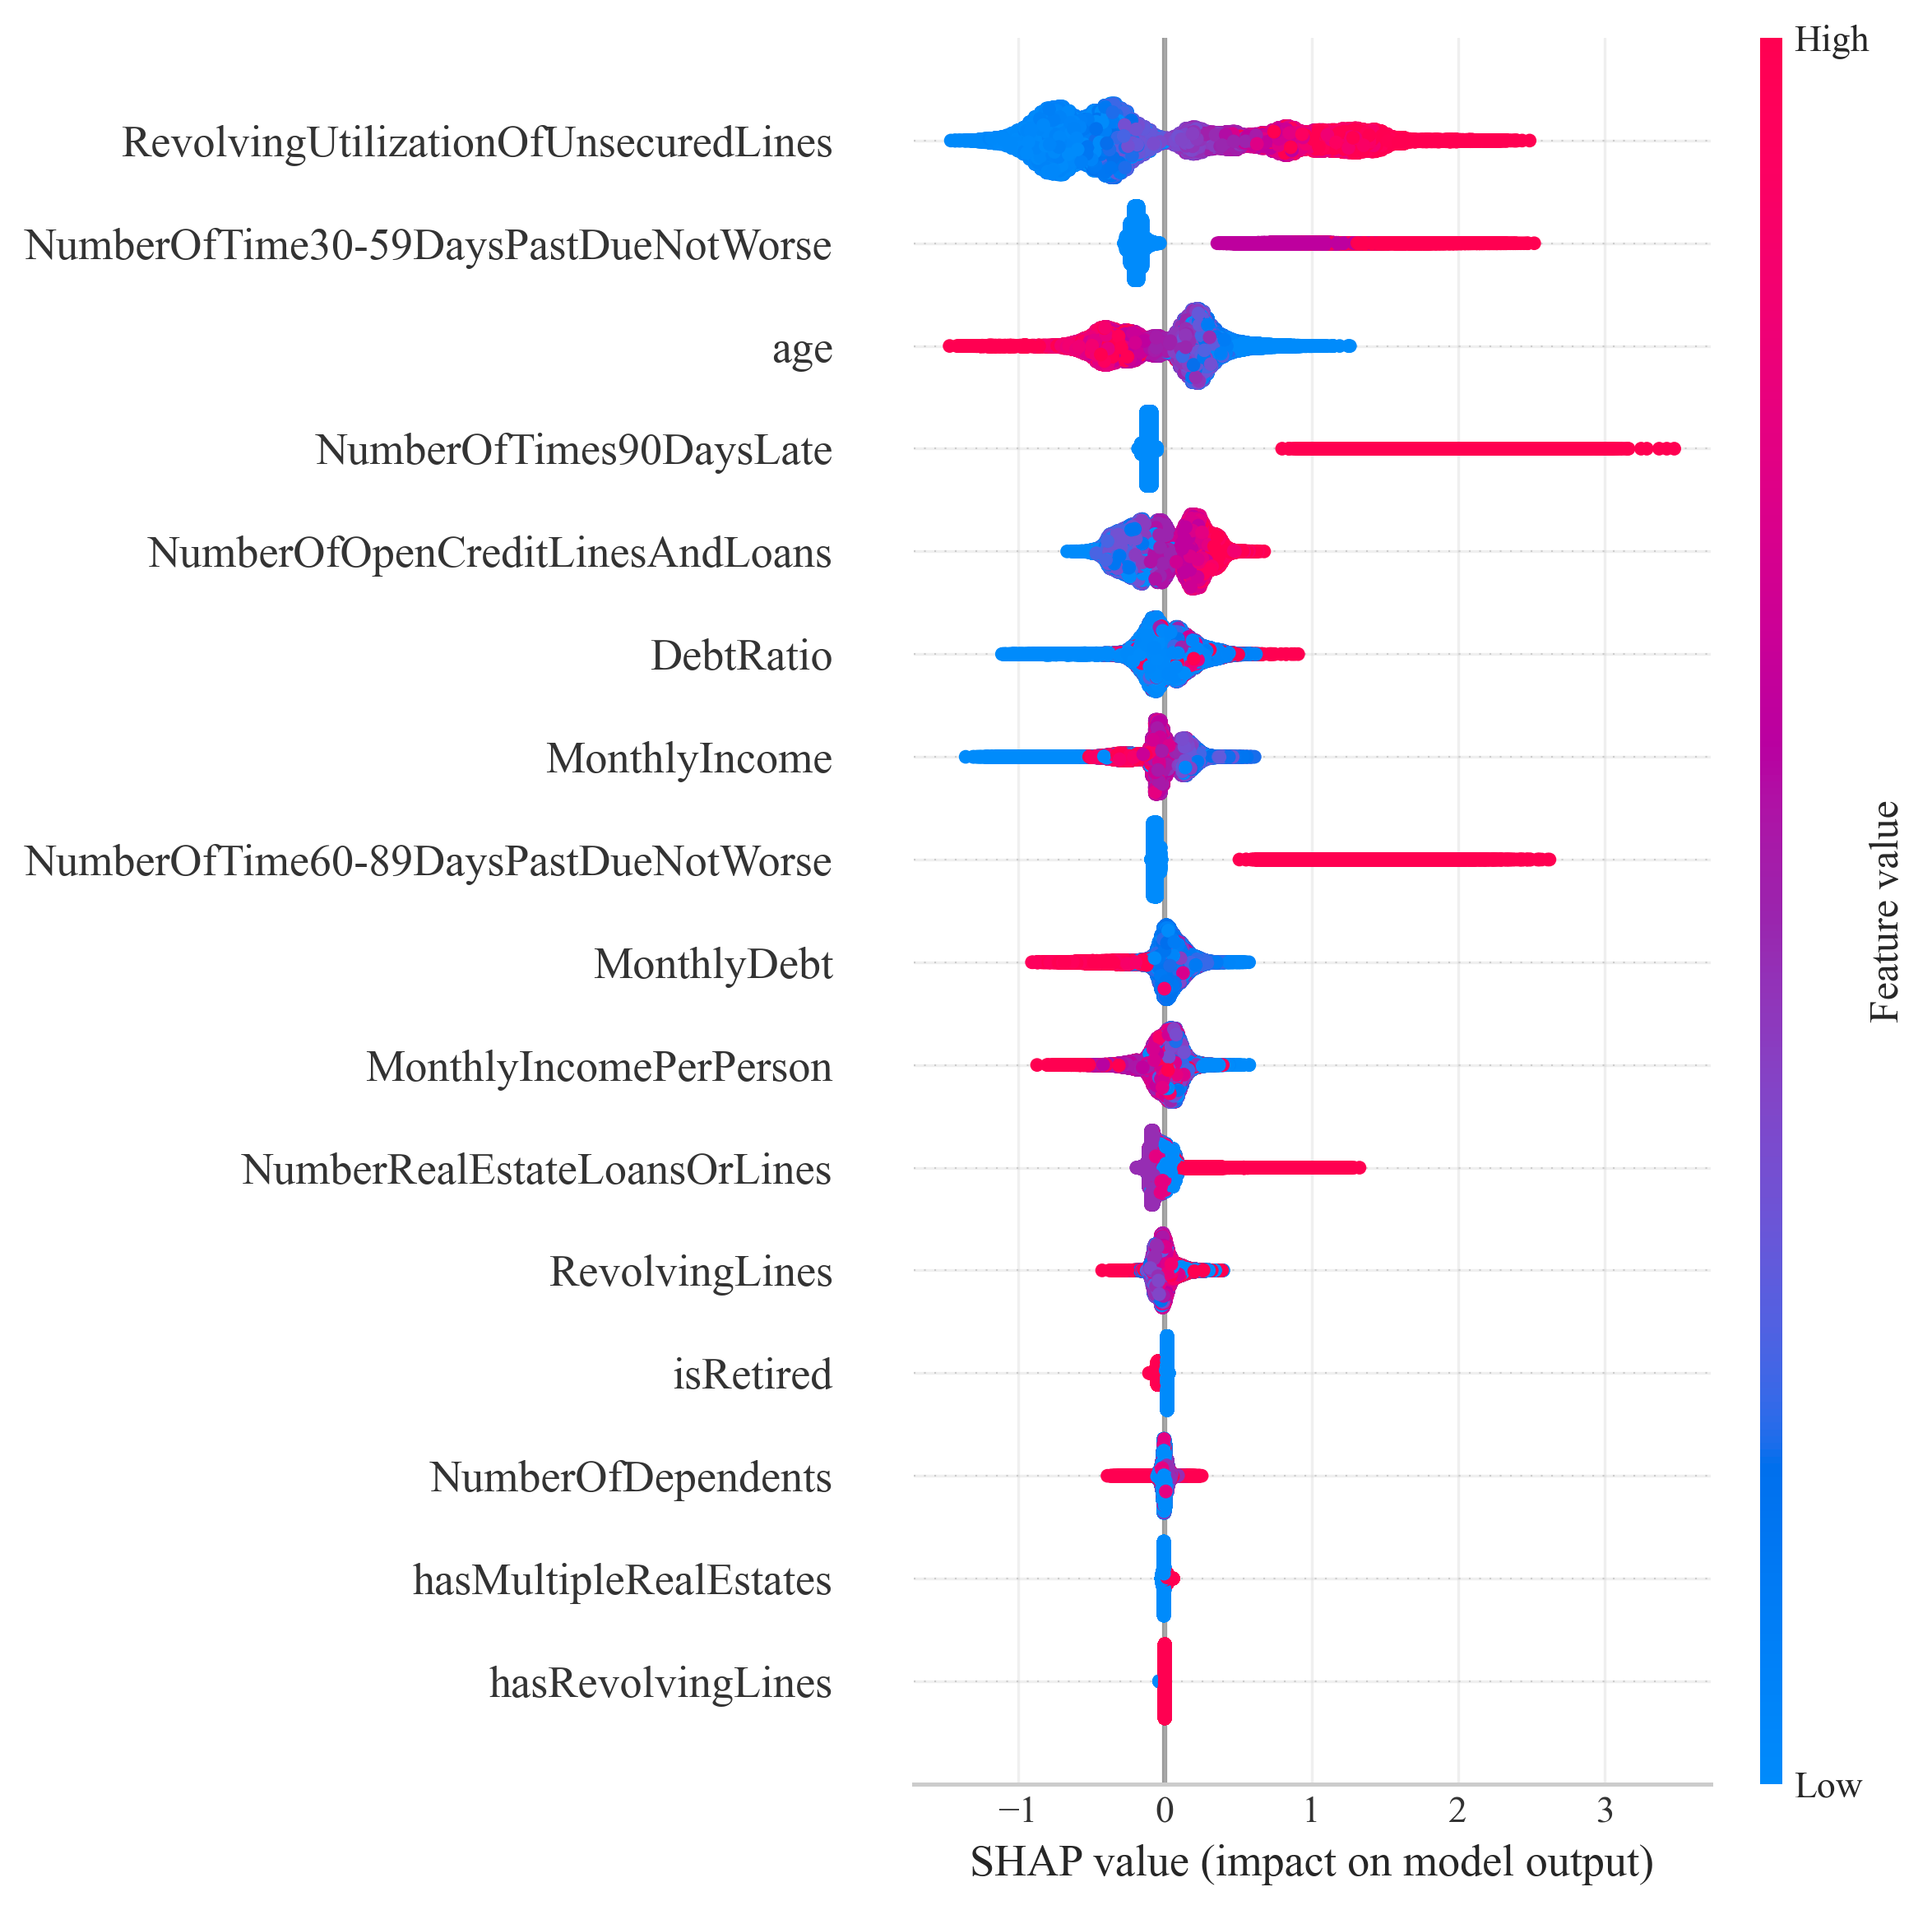

In [69]:
# SHAP-basierte Feature Importance
X = pd.DataFrame(x_train, columns=x_train.columns.to_list())
explainer = shap.TreeExplainer(best_lgb_estimator)
shap_values = explainer.shap_values(X)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X, show=False)

plt.savefig('figs/feature_importance_lightgbm_shap.svg', format='svg', dpi=300, bbox_inches='tight')
plt.savefig('figs/feature_importance_lightgbm_shap.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

In [70]:
# SHAP-Analyse für Testdaten
shap_values_test = explainer.shap_values(x_test)
feature_names = list(x_test.columns)
expected_value = explainer.expected_value

np.random.seed(42)

# False Positive
false_positive_indices = np.where((y_pred_lgb == 1) & (y_test == 0))[0]
false_positive_index = false_positive_indices[0]

# False Negative
false_negative_indices = np.where((y_pred_lgb == 0) & (y_test == 1))[0]
false_negative_index = false_negative_indices[0]

print(f"False Positive Beispiel (Index: {false_positive_index}):")
print(f"   Vorhergesagte Wahrscheinlichkeit: {y_pred_proba_lgb[false_positive_index]:.4f}")
print(f"   Tatsächliche Klasse: {y_test.iloc[false_positive_index]}")

print(f"\nFalse Negative Beispiel (Index: {false_negative_index}):")
print(f"   Vorhergesagte Wahrscheinlichkeit: {y_pred_proba_lgb[false_negative_index]:.4f}")
print(f"   Tatsächliche Klasse: {y_test.iloc[false_negative_index]}")

False Positive Beispiel (Index: 4):
   Vorhergesagte Wahrscheinlichkeit: 0.7773
   Tatsächliche Klasse: 0

False Negative Beispiel (Index: 100):
   Vorhergesagte Wahrscheinlichkeit: 0.4582
   Tatsächliche Klasse: 1


In [71]:
# Rücktransformation der Feature-Werte für Interpretierbarkeit
# WICHTIG: SHAP-Werte bleiben unverändert, nur Feature-Werte werden rücktransformiert

lambda_value = 0.15
x_test_original = x_test.copy()

for feature in skewness_train.index:
    if feature in x_test_original.columns:
        # Inverse Box-Cox Transformation: x_original = ((λ*x_transformed + 1)^(1/λ)) - 1
        x_test_original[feature] = np.power(lambda_value * x_test_original[feature] + 1, 1/lambda_value) - 1

print("Feature-Werte erfolgreich rücktransformiert für bessere Interpretierbarkeit")

Feature-Werte erfolgreich rücktransformiert für bessere Interpretierbarkeit



  False Positive Beispiel (Index: 4)
   • Tatsächliche Klasse: Good Risk (0)
   • Modell-Vorhersage: 0.7773 (Risikowahrscheinlichkeit) (Bad Risk Wahrscheinlichkeit)
   • Modell-Entscheidung: Bad Risk

Top 5 Faktoren die das Risiko erhöhen:
   RevolvingUtilizationOfUnsecuredLines: 0.655 → SHAP: +0.6851
   NumberOfTime30-59DaysPastDueNotWorse: 1.000 → SHAP: +0.6816
   DebtRatio: 0.991 → SHAP: +0.2907
   MonthlyDebt: 5039.009 → SHAP: +0.1784
   NumberOfOpenCreditLinesAndLoans: 13.000 → SHAP: +0.1305

Top 5 Faktoren die das Risiko verringern:
   NumberOfTimes90DaysLate: 0.000 → SHAP: -0.1083
   NumberRealEstateLoansOrLines: 1.000 → SHAP: -0.0800
   NumberOfTime60-89DaysPastDueNotWorse: 0.000 → SHAP: -0.0627
   hasMultipleRealEstates: 0.000 → SHAP: -0.0090
   NumberOfDependents: 0.000 → SHAP: -0.0066


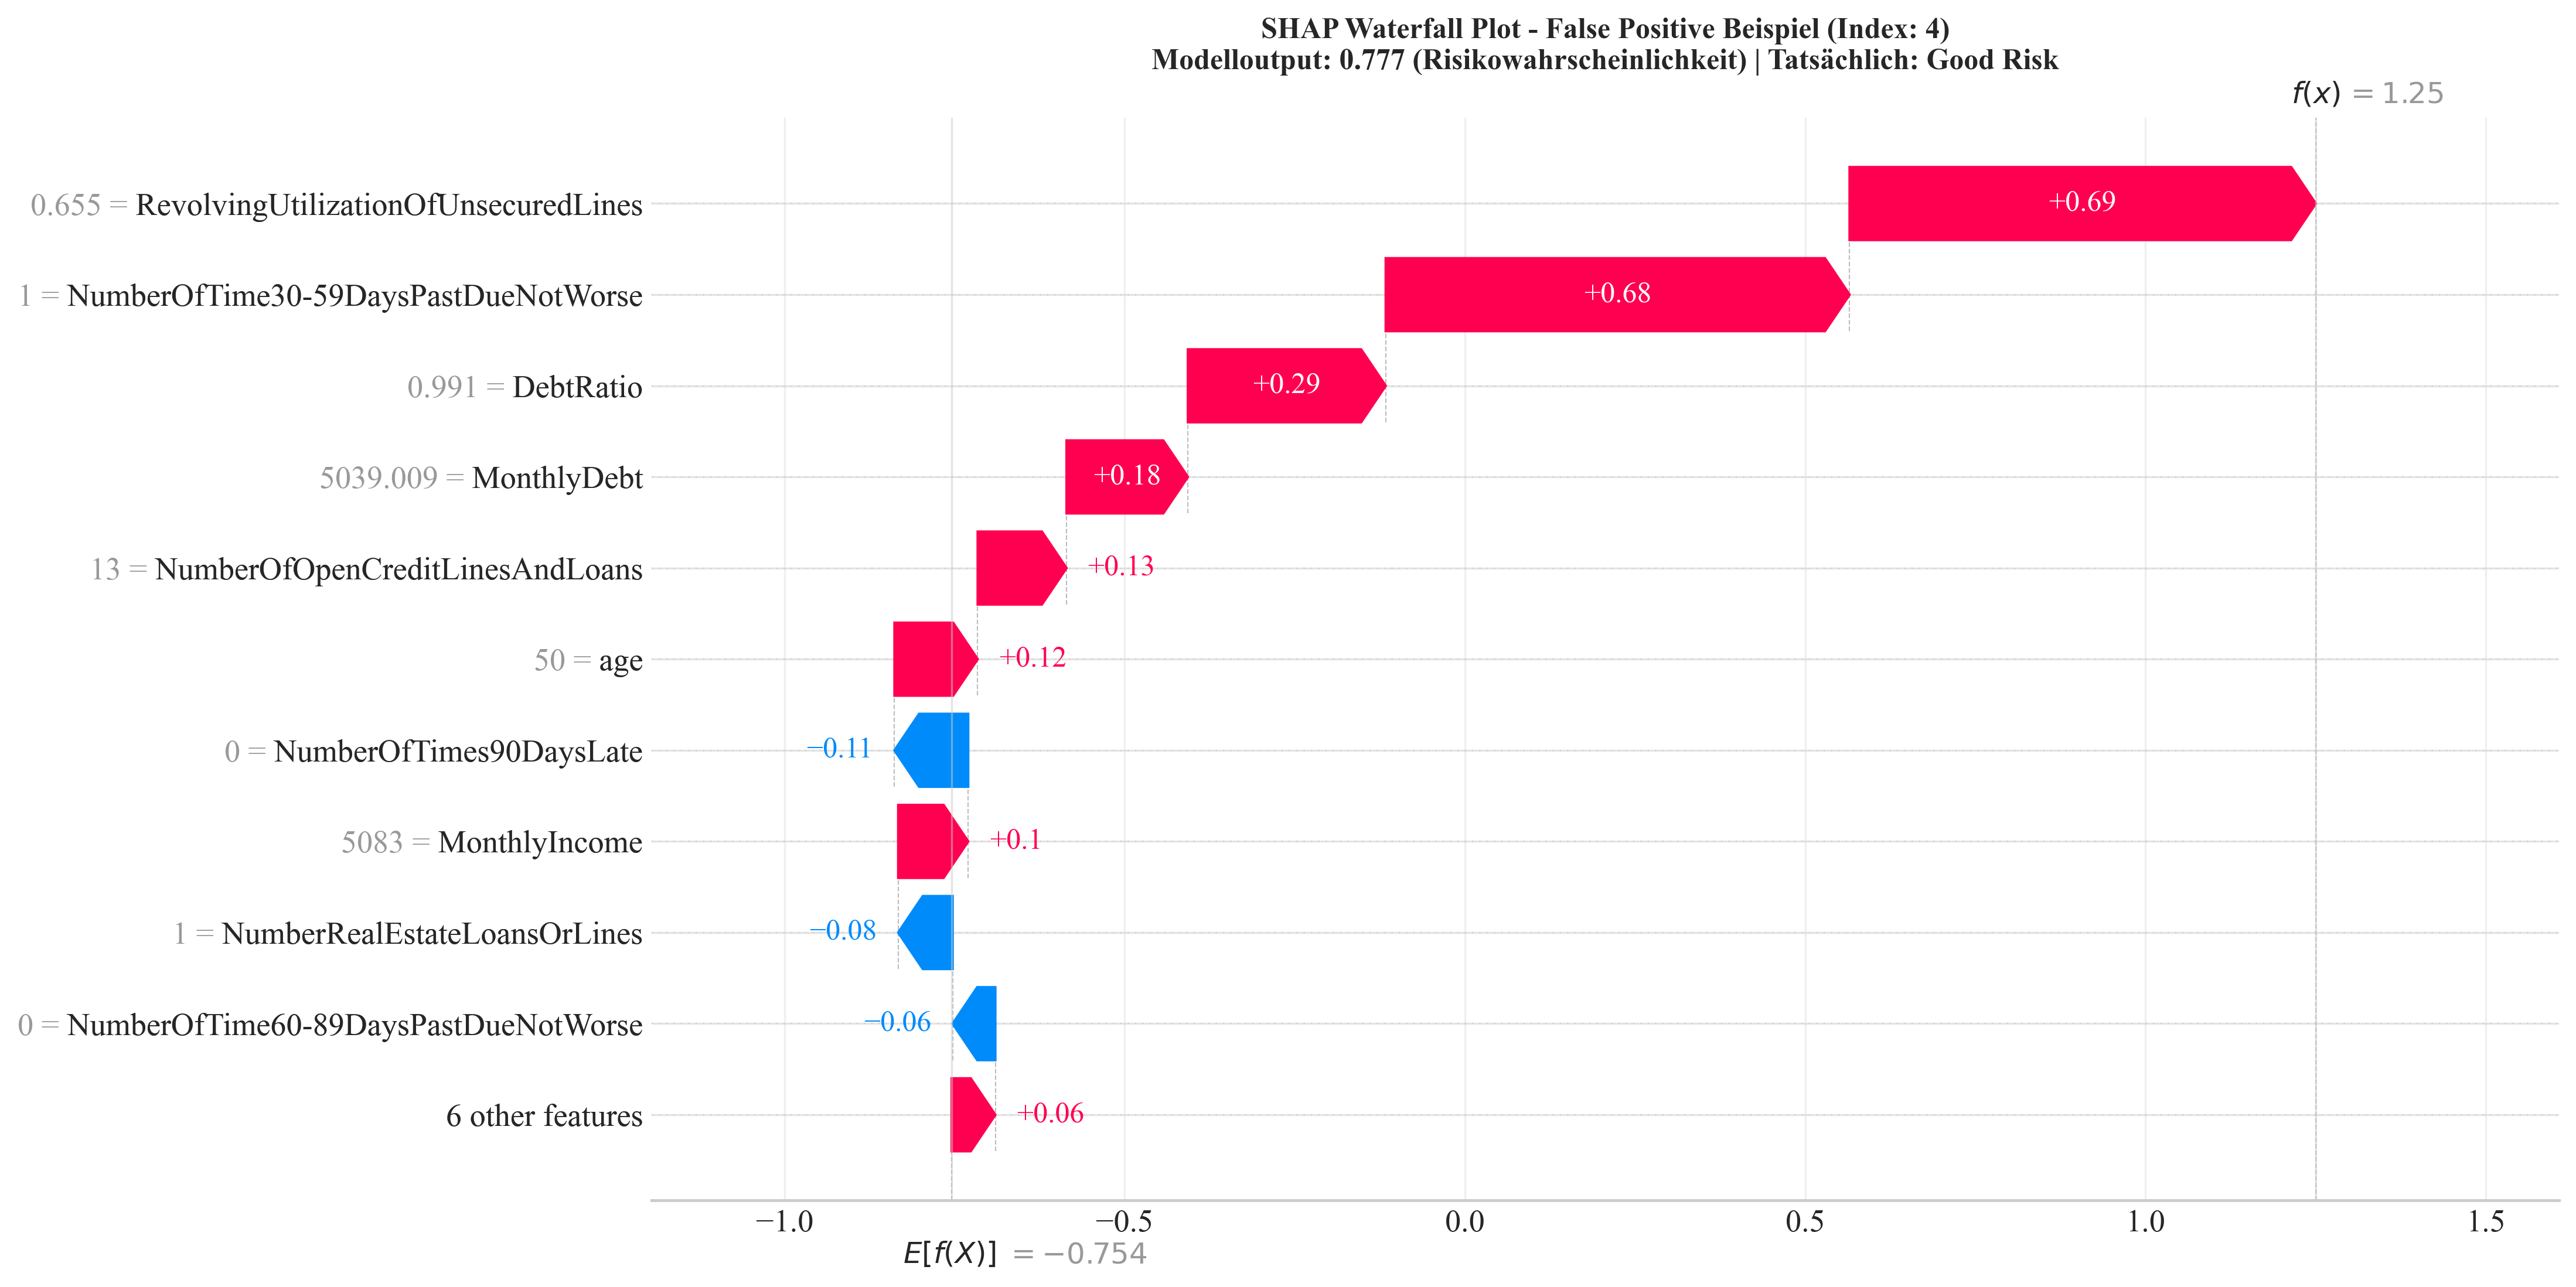


 UMRECHNUNG f(x) → MODELLOUTPUT:
   f(x) = 1.250178 (Logit-Raum, direkte SHAP-Summe)
   Modelloutput = sigmoid(f(x)) = 1/(1+e^(-1.250178)) = 0.777331
   Unterschied: f(x) ist im Logit-Raum, Modelloutput ist Wahrscheinlichkeit nach Sigmoid-Transformation



  False Negative Beispiel (Index: 100)
   • Tatsächliche Klasse: Bad Risk (1)
   • Modell-Vorhersage: 0.4582 (Bad Risk Wahrscheinlichkeit)
   • Modell-Entscheidung: Good Risk

Top 5 Faktoren die das Risiko erhöhen:
   RevolvingUtilizationOfUnsecuredLines: 0.969 → SHAP: +1.5113
   MonthlyIncome: 3800.000 → SHAP: +0.1653
   DebtRatio: 0.409 → SHAP: +0.0208
   isRetired: 0.000 → SHAP: +0.0188
   hasRevolvingLines: 1.000 → SHAP: +0.0002

Top 5 Faktoren die das Risiko verringern:
   NumberOfOpenCreditLinesAndLoans: 5.000 → SHAP: -0.2868
   MonthlyIncomePerPerson: 3800.000 → SHAP: -0.2415
   NumberOfTime30-59DaysPastDueNotWorse: 0.000 → SHAP: -0.1942
   NumberOfTimes90DaysLate: 0.000 → SHAP: -0.1448
   NumberRealEstateLoansOrLines: 1.000 

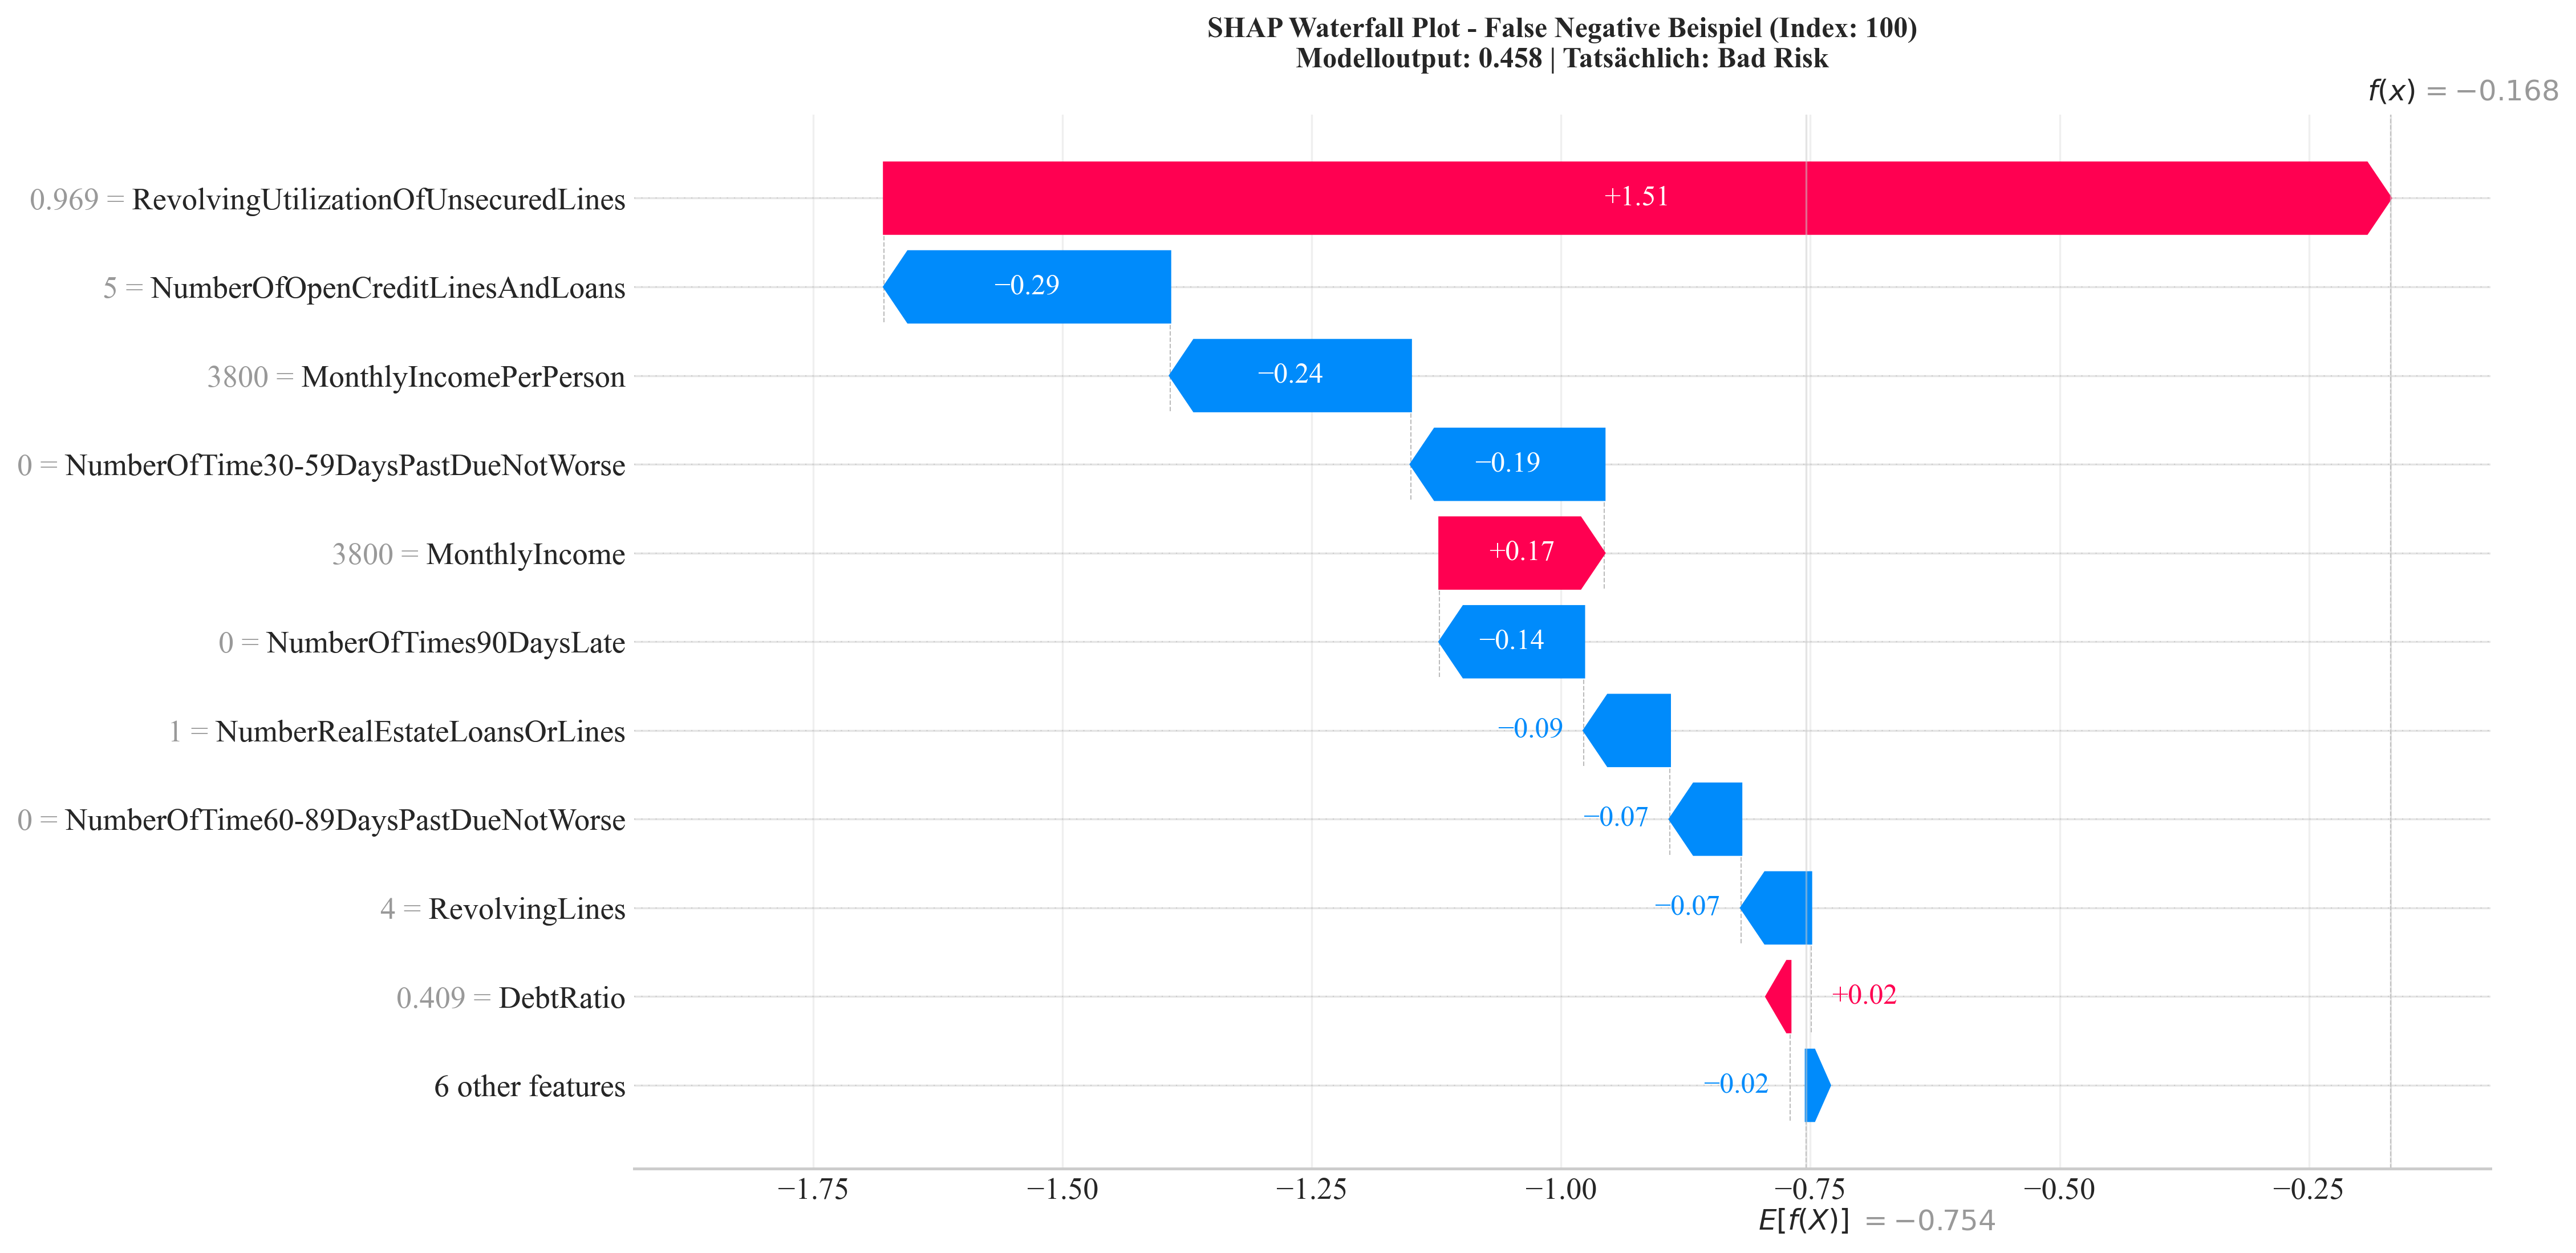


  UMRECHNUNG f(x) → MODELLOUTPUT:
   f(x) = -0.167752 (Logit-Raum, direkte SHAP-Summe)
   Modelloutput = sigmoid(f(x)) = 1/(1+e^(--0.167752)) = 0.458160
   Unterschied: f(x) ist im Logit-Raum, Modelloutput ist Wahrscheinlichkeit nach Sigmoid-Transformation


In [72]:
plt.tight_layout()
# False Positive Beispiel
# ===================================================================

print(f"\n  False Positive Beispiel (Index: {false_positive_index})")
print(f"   • Tatsächliche Klasse: {'Bad Risk (1)' if y_test.iloc[false_positive_index] == 1 else 'Good Risk (0)'}")
print(f"   • Modell-Vorhersage: {y_pred_proba_lgb[false_positive_index]:.4f} (Risikowahrscheinlichkeit) (Bad Risk Wahrscheinlichkeit)")
print(f"   • Modell-Entscheidung: {'Bad Risk' if y_pred_proba_lgb[false_positive_index] > 0.5 else 'Good Risk'}")

# Analyse der SHAP-Beiträge
bad_feature_values = x_test_original.iloc[false_positive_index].values
bad_contributions = pd.DataFrame({
    'Feature': feature_names,
    'Value': bad_feature_values,
    'SHAP_Contribution': shap_values_test[false_positive_index]
})

# Top Einflussfaktoren
top_positive_bad = bad_contributions[bad_contributions['SHAP_Contribution'] > 0].nlargest(5, 'SHAP_Contribution')
top_negative_bad = bad_contributions[bad_contributions['SHAP_Contribution'] < 0].nsmallest(5, 'SHAP_Contribution')

print("\nTop 5 Faktoren die das Risiko erhöhen:")
for _, row in top_positive_bad.iterrows():
    print(f"   {row['Feature']}: {row['Value']:.3f} → SHAP: +{row['SHAP_Contribution']:.4f}")

print("\nTop 5 Faktoren die das Risiko verringern:")
for _, row in top_negative_bad.iterrows():
    print(f"   {row['Feature']}: {row['Value']:.3f} → SHAP: {row['SHAP_Contribution']:.4f}")

# SHAP Waterfall Plot
shap_explanation_fp = shap.Explanation(
    values=shap_values_test[false_positive_index],
    base_values=expected_value,
    data=x_test_original.iloc[false_positive_index].values,
    feature_names=feature_names
)

shap.plots.waterfall(shap_explanation_fp, max_display=11, show=False)

fig = plt.gcf()
fig.set_size_inches(14, 8)
plt.title(f'SHAP Waterfall Plot - False Positive Beispiel (Index: {false_positive_index})\n'
          f'Modelloutput: {y_pred_proba_lgb[false_positive_index]:.3f} (Risikowahrscheinlichkeit) | Tatsächlich: {"Bad Risk" if y_test.iloc[false_positive_index] == 1 else "Good Risk"}', 
          fontweight='bold', fontsize=12, pad=20)

plt.savefig("figs/false_positive_shap_waterfall.svg", format="svg", dpi=300, bbox_inches='tight')
plt.savefig("figs/false_positive_shap_waterfall.pdf", format="pdf", dpi=300, bbox_inches='tight')
plt.show()

# Modelloutput-Berechnung
fp_logit = expected_value + np.sum(shap_values_test[false_positive_index])
fp_probability = 1 / (1 + np.exp(-fp_logit))
print(f"\n UMRECHNUNG f(x) → MODELLOUTPUT:")
print(f"   f(x) = {fp_logit:.6f} (Logit-Raum, direkte SHAP-Summe)")
print(f"   Modelloutput = sigmoid(f(x)) = 1/(1+e^(-{fp_logit:.6f})) = {fp_probability:.6f}")
print(f"   Unterschied: f(x) ist im Logit-Raum, Modelloutput ist Wahrscheinlichkeit nach Sigmoid-Transformation")

print("\n" + "="*60 + "\n")

# False Negative Beispiel
# ===================================================================

print(f"\n  False Negative Beispiel (Index: {false_negative_index})")
print(f"   • Tatsächliche Klasse: {'Bad Risk (1)' if y_test.iloc[false_negative_index] == 1 else 'Good Risk (0)'}")
print(f"   • Modell-Vorhersage: {y_pred_proba_lgb[false_negative_index]:.4f} (Bad Risk Wahrscheinlichkeit)")
print(f"   • Modell-Entscheidung: {'Bad Risk' if y_pred_proba_lgb[false_negative_index] > 0.5 else 'Good Risk'}")

# Analyse der SHAP-Beiträge
good_feature_values = x_test_original.iloc[false_negative_index].values
good_contributions = pd.DataFrame({
    'Feature': feature_names,
    'Value': good_feature_values,
    'SHAP_Contribution': shap_values_test[false_negative_index]
})

# Top Einflussfaktoren
top_positive_good = good_contributions[good_contributions['SHAP_Contribution'] > 0].nlargest(5, 'SHAP_Contribution')
top_negative_good = good_contributions[good_contributions['SHAP_Contribution'] < 0].nsmallest(5, 'SHAP_Contribution')

print("\nTop 5 Faktoren die das Risiko erhöhen:")
for _, row in top_positive_good.iterrows():
    print(f"   {row['Feature']}: {row['Value']:.3f} → SHAP: +{row['SHAP_Contribution']:.4f}")

print("\nTop 5 Faktoren die das Risiko verringern:")
for _, row in top_negative_good.iterrows():
    print(f"   {row['Feature']}: {row['Value']:.3f} → SHAP: {row['SHAP_Contribution']:.4f}")


# SHAP Waterfall Plot
shap_explanation_fn = shap.Explanation(
    values=shap_values_test[false_negative_index],
    base_values=expected_value,
    data=x_test_original.iloc[false_negative_index].values,
    feature_names=feature_names
)

shap.plots.waterfall(shap_explanation_fn, max_display=11, show=False)

fig = plt.gcf()
fig.set_size_inches(14, 8)
plt.title(f'SHAP Waterfall Plot - False Negative Beispiel (Index: {false_negative_index})\n'
          f'Modelloutput: {y_pred_proba_lgb[false_negative_index]:.3f} | Tatsächlich: {"Bad Risk" if y_test.iloc[false_negative_index] == 1 else "Good Risk"}', 
          fontweight='bold', fontsize=12, pad=20)

plt.savefig("figs/false_negative_shap_waterfall.svg", format="svg", dpi=300, bbox_inches='tight')
plt.savefig("figs/false_negative_shap_waterfall.pdf", format="pdf", dpi=300, bbox_inches='tight')
plt.show()

# Modelloutput-Berechnung
fn_logit = expected_value + np.sum(shap_values_test[false_negative_index])
fn_probability = 1 / (1 + np.exp(-fn_logit))
print(f"\n  UMRECHNUNG f(x) → MODELLOUTPUT:")
print(f"   f(x) = {fn_logit:.6f} (Logit-Raum, direkte SHAP-Summe)")
print(f"   Modelloutput = sigmoid(f(x)) = 1/(1+e^(-{fn_logit:.6f})) = {fn_probability:.6f}")
print(f"   Unterschied: f(x) ist im Logit-Raum, Modelloutput ist Wahrscheinlichkeit nach Sigmoid-Transformation")

In [73]:
# Visualisierung der SHAP-Wasserfall-Diagramme für Wahrscheinlichkeiten und Logits
def sigmoid(x):
    """Sigmoid-Funktion zur Umwandlung von Logit-Werten in Wahrscheinlichkeiten"""
    return 1 / (1 + np.exp(-x))

def create_probability_waterfall(shap_values_instance, feature_values, feature_names, 
                                expected_value, title, filename_prefix, max_features=10):
    """
    Erstellt einen Plot im Wahrscheinlichkeitsraum statt Logit-Raum
    """
    # Sortiere Features nach SHAP-Wert Magnitude
    feature_importance = np.abs(shap_values_instance)
    sorted_indices = np.argsort(feature_importance)[::-1][:max_features]
    remaining_indices = np.setdiff1d(np.arange(len(feature_values)), sorted_indices)
    
    # Datenaufbau
    current_logit = expected_value
    data = []
    
    data.append({
        'name': 'Expected Value',
        'logit': expected_value,
        'probability': sigmoid(expected_value),
        'cumulative_logit': current_logit,
        'cumulative_prob': sigmoid(current_logit),
        'contribution': 0
    })
    
    # Einzelne Feature-Beiträge
    for idx in sorted_indices:
        contribution = shap_values_instance[idx]
        current_logit += contribution
        
        data.append({
            'name': f"{feature_names[idx]}",
            'value': feature_values[idx],
            'logit': contribution,
            'probability': sigmoid(current_logit) - sigmoid(current_logit - contribution),
            'cumulative_logit': current_logit,
            'cumulative_prob': sigmoid(current_logit),
            'contribution': contribution
        })

    # Verbleibende Features als Gruppe
    if len(remaining_indices) > 0:
        remaining_contribution = np.sum(shap_values_instance[remaining_indices])
        current_logit += remaining_contribution
        
        data.append({
            'name': 'Remaining Features',
            'logit': remaining_contribution,
            'probability': sigmoid(current_logit) - sigmoid(current_logit - remaining_contribution),
            'cumulative_logit': current_logit,
            'cumulative_prob': sigmoid(current_logit),
            'contribution': remaining_contribution
        })
    
    # Finale Vorhersage
    final_logit = expected_value + np.sum(shap_values_instance)
    data.append({
        'name': 'Final Prediction',
        'logit': final_logit,
        'probability': sigmoid(final_logit),
        'cumulative_logit': final_logit,
        'cumulative_prob': sigmoid(final_logit),
        'contribution': 0
    })
    
    # Plot-Erstellung
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))
    
    # Wahrscheinlichkeitsraum
    probabilities = [item['cumulative_prob'] for item in data]
    labels = [item['name'] for item in data]
    
    colors = ['gray']
    for i in range(1, len(data)-1):
        if data[i]['contribution'] > 0:
            colors.append('#FF6B6B')  # Erhöhtes Risiko
        else:
            colors.append('#51CF66')  # Verringertes Risiko
    colors.append('#4ECDC4')  # Finale Vorhersage
    
    bars = ax1.bar(range(len(probabilities)), probabilities, color=colors, alpha=0.7)
    ax1.set_xticks(range(len(labels)))
    ax1.set_xticklabels(labels, rotation=45, ha='right')
    ax1.set_ylabel('Wahrscheinlichkeit (%)')
    ax1.set_title(f'{title}\nKumulative Wahrscheinlichkeiten', fontweight='bold', fontsize=14)
    ax1.set_ylim(0, 1)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
    ax1.grid(axis='y', alpha=0.3)
    
    for i, (bar, prob) in enumerate(zip(bars, probabilities)):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{prob:.1%}', ha='center', va='bottom', fontweight='bold')
    
    # Logit-Raum
    individual_logits = [expected_value]
    for i in range(1, len(data)-1):
        individual_logits.append(data[i]['contribution'])
    individual_logits.append(data[-1]['logit'])
    
    logit_colors = ['gray']
    for i in range(1, len(individual_logits)-1):
        if individual_logits[i] > 0:
            logit_colors.append('#FF6B6B')
        else:
            logit_colors.append('#51CF66')
    logit_colors.append('#4ECDC4')
    
    bars2 = ax2.bar(range(len(individual_logits)), individual_logits, color=logit_colors, alpha=0.7)
    ax2.set_xticks(range(len(labels)))
    ax2.set_xticklabels(labels, rotation=45, ha='right')
    ax2.set_ylabel('SHAP-Beitrag (Logit)')
    ax2.set_title('SHAP-Beiträge im Logit-Raum', fontweight='bold', fontsize=14)
    ax2.grid(axis='y', alpha=0.3)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    for i, (bar, logit) in enumerate(zip(bars2, individual_logits)):
        height = bar.get_height()
        if height >= 0:
            va = 'bottom'
            y_pos = height + 0.02
        else:
            va = 'top'
            y_pos = height - 0.02
        ax2.text(bar.get_x() + bar.get_width()/2., y_pos,
                f'{logit:.3f}', ha='center', va=va, fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    
    # Speichern
    plt.savefig(f"figs/{filename_prefix}_probability_waterfall.svg", format="svg", dpi=300, bbox_inches='tight')
    plt.savefig(f"figs/{filename_prefix}_probability_waterfall.pdf", format="pdf", dpi=300, bbox_inches='tight')
    
    plt.show()
    
    # Zusammenfassung
    print(f"\nZusammenfassung {title}:")
    print(f"   Expected Value: {sigmoid(expected_value):.1%} (Baseline)")
    print(f"   Final Prediction: {sigmoid(final_logit):.1%}")
    print(f"   Änderung: {sigmoid(final_logit) - sigmoid(expected_value):+.1%}")
    
    return data

FALSE POSITIVE ANALYSE (Index: 4)


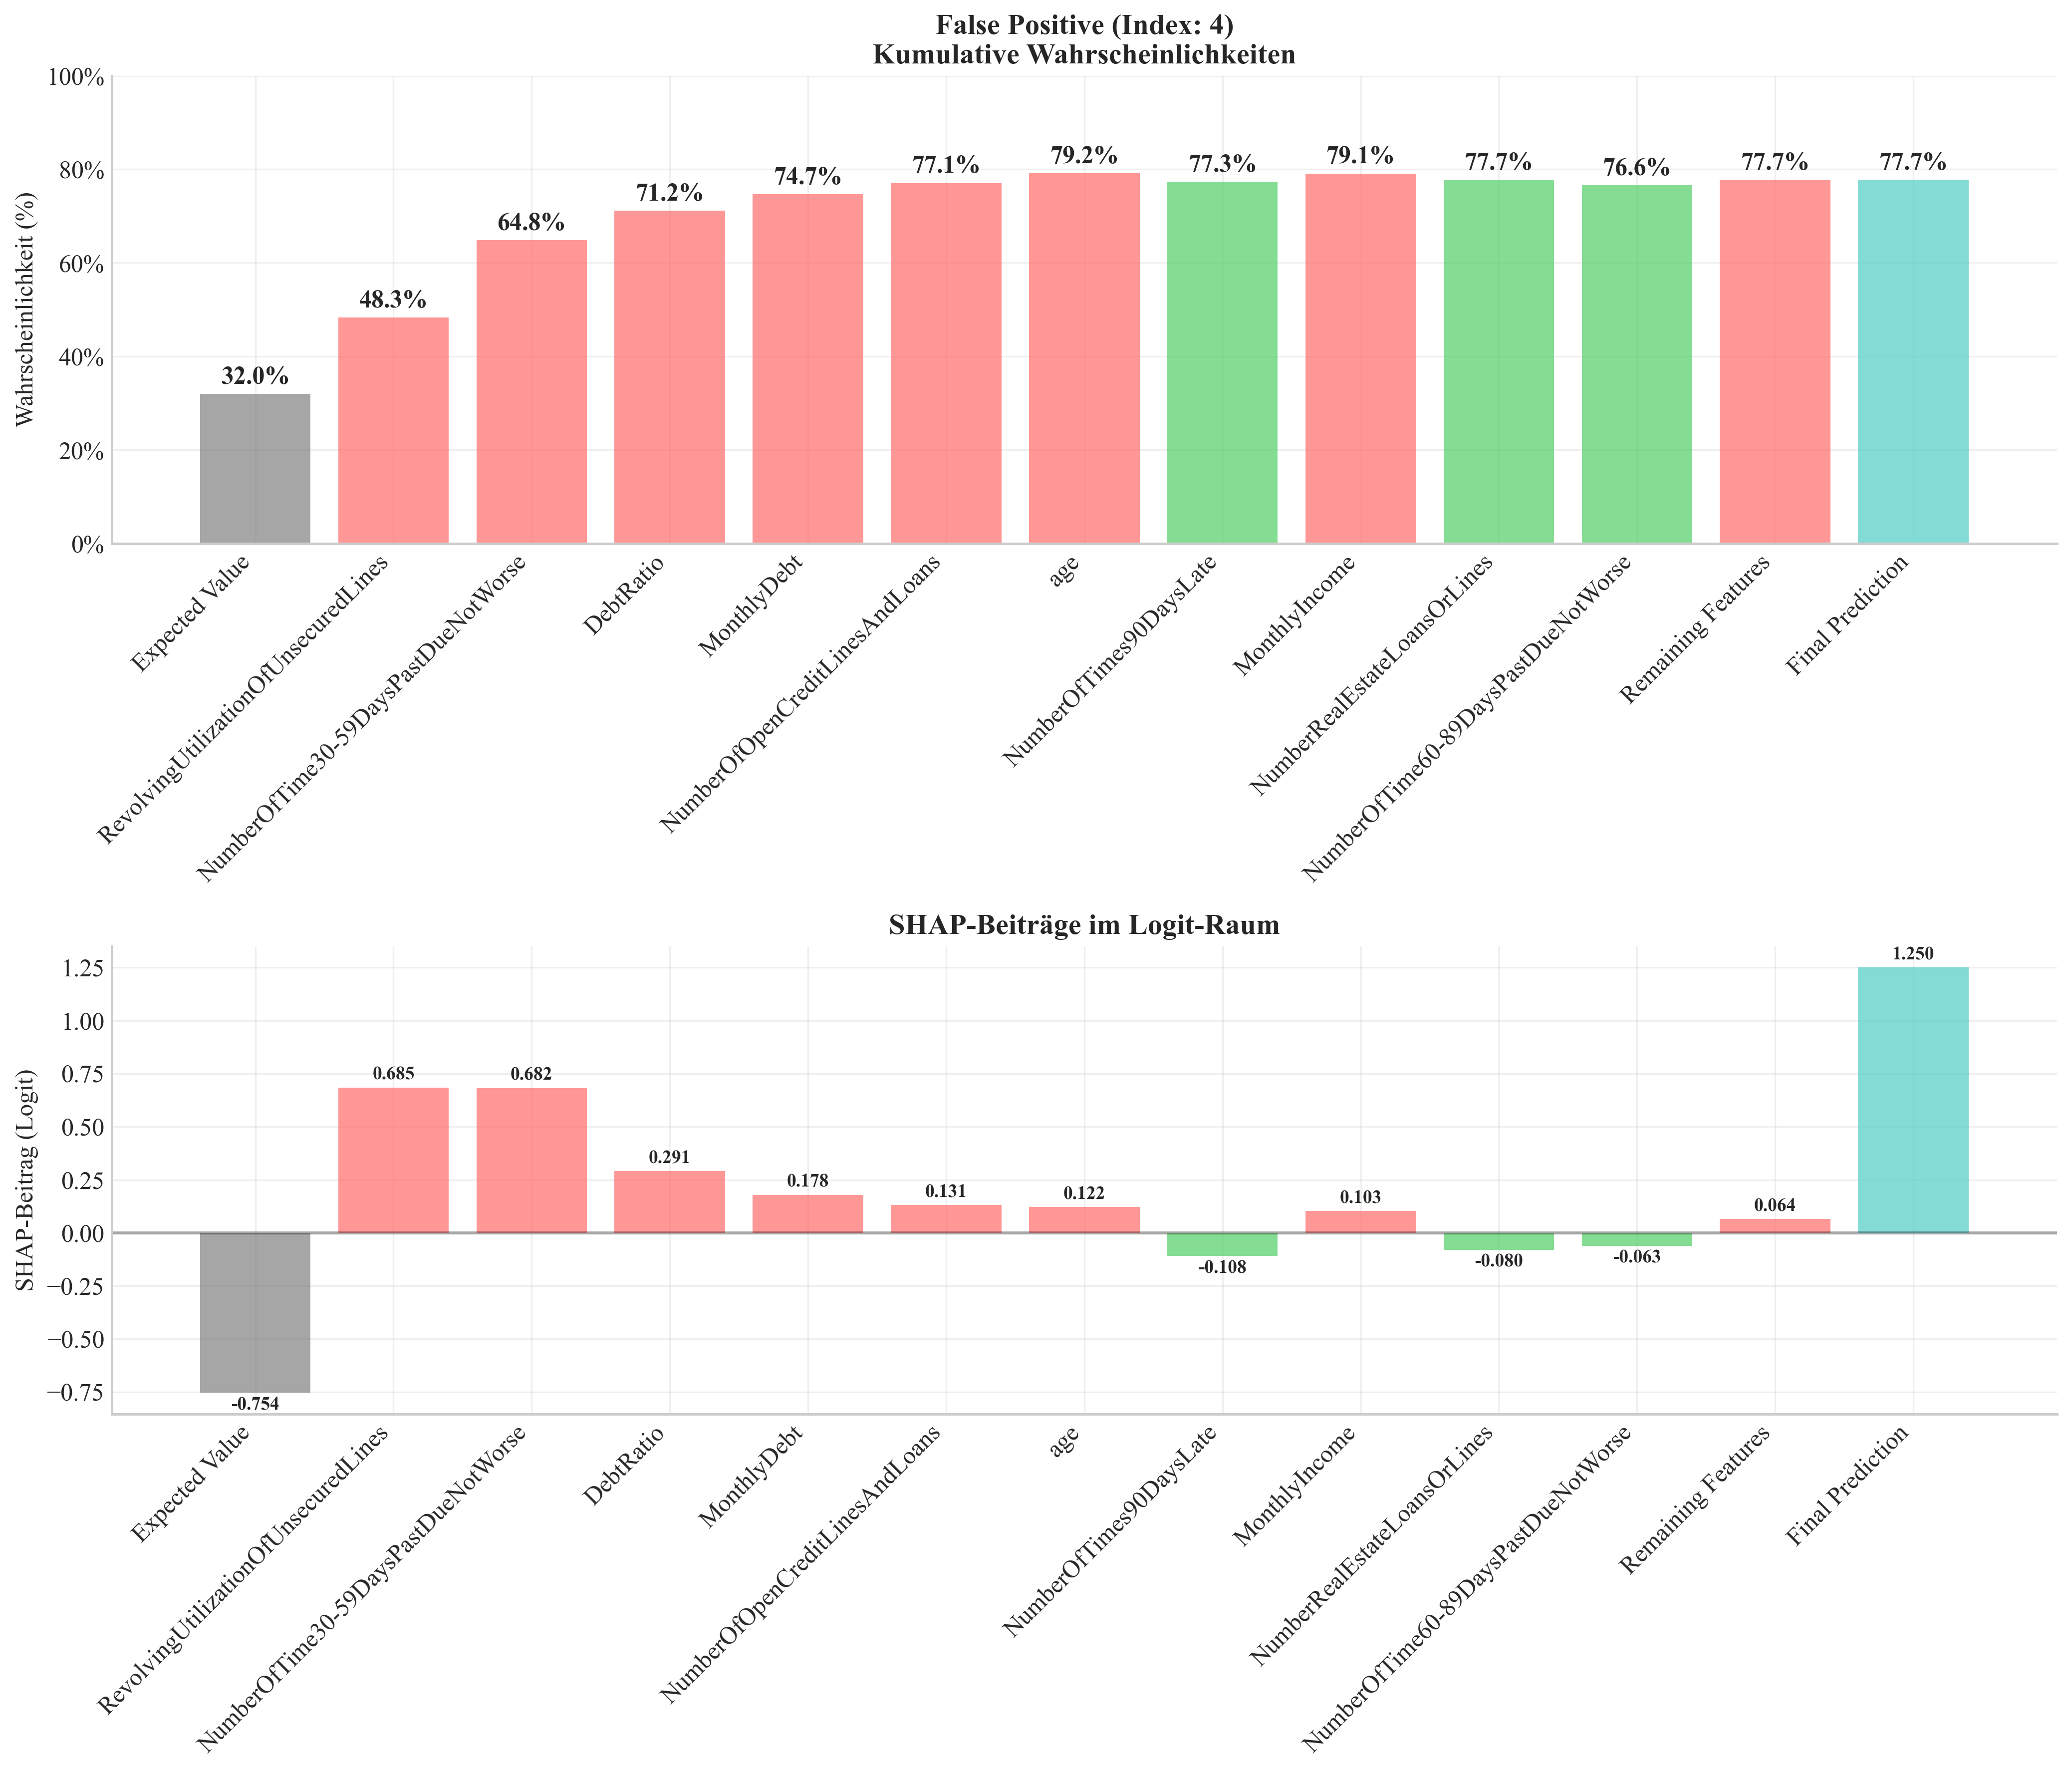


Zusammenfassung False Positive (Index: 4):
   Expected Value: 32.0% (Baseline)
   Final Prediction: 77.7%
   Änderung: +45.7%

--------------------------------------------------

FALSE NEGATIVE ANALYSE (Index: 100)


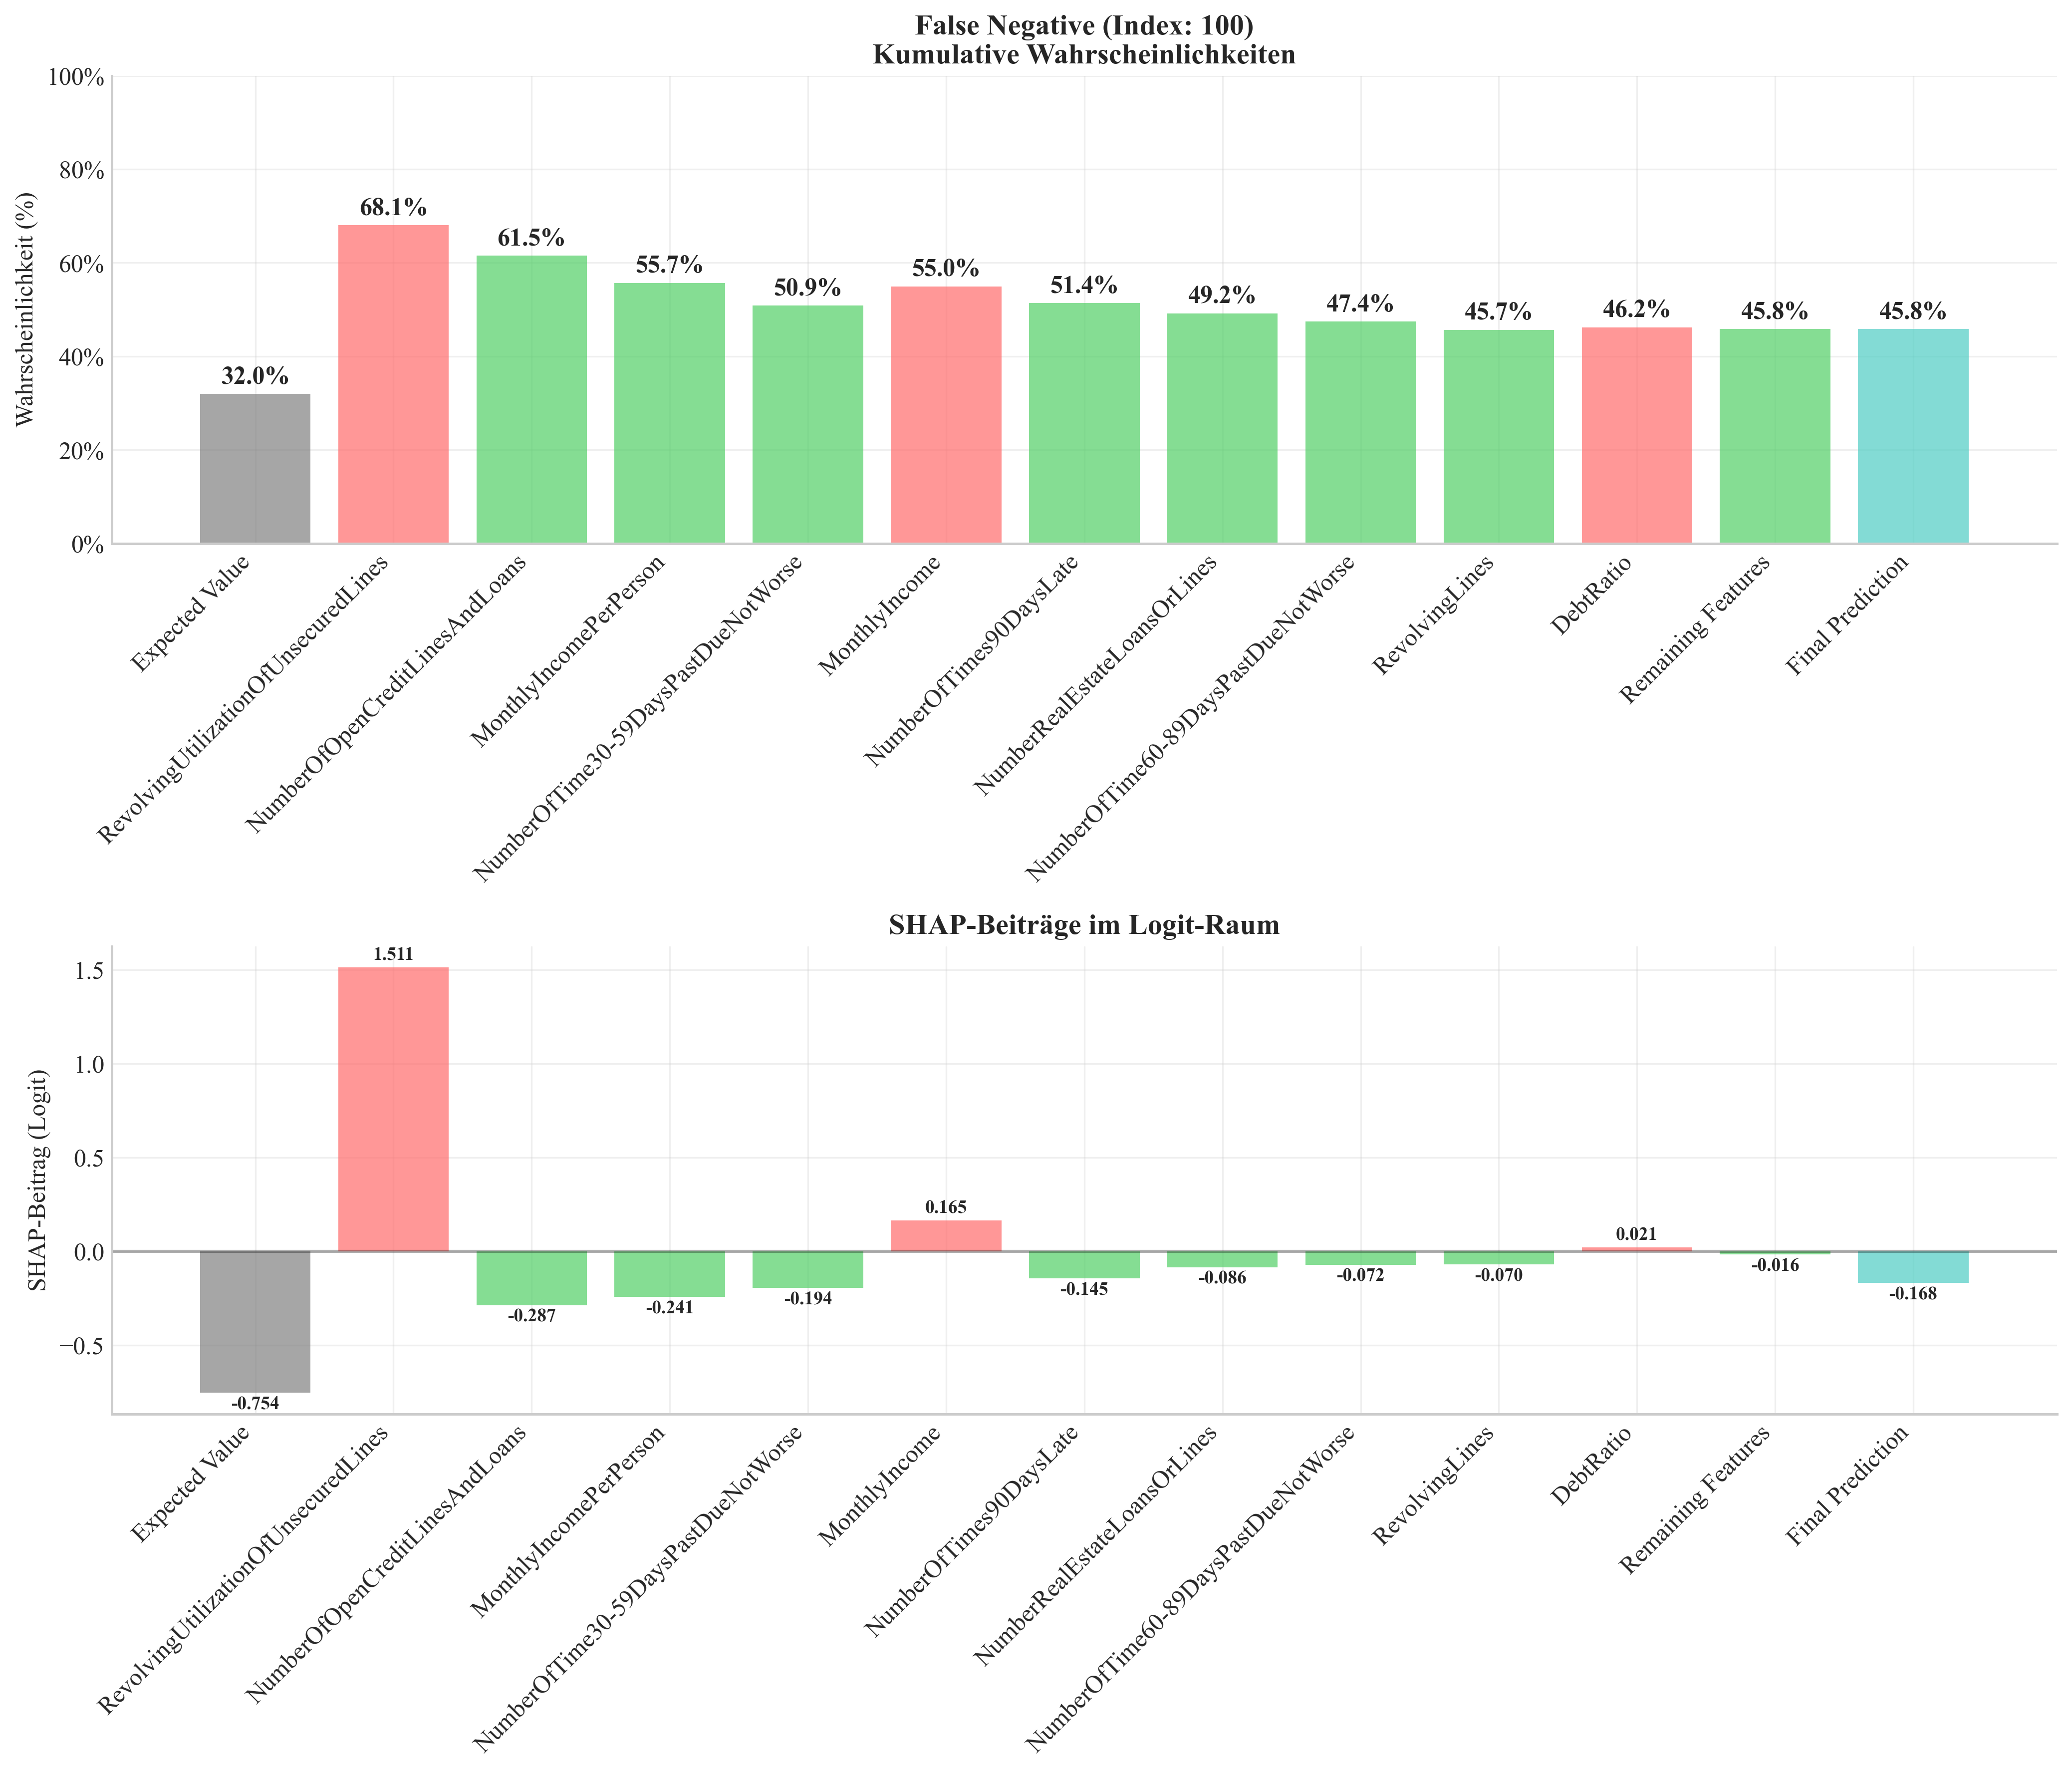


Zusammenfassung False Negative (Index: 100):
   Expected Value: 32.0% (Baseline)
   Final Prediction: 45.8%
   Änderung: +13.8%


In [74]:
# False Positive Analyse
print(f"FALSE POSITIVE ANALYSE (Index: {false_positive_index})")
fp_waterfall = create_probability_waterfall(
    shap_values_test[false_positive_index],
    x_test_original.iloc[false_positive_index].values,
    feature_names,
    expected_value,
    f"False Positive (Index: {false_positive_index})",
    "false_positive"
)

print("\n" + "-"*50)

# False Negative Analyse
print(f"\nFALSE NEGATIVE ANALYSE (Index: {false_negative_index})")
fn_waterfall = create_probability_waterfall(
    shap_values_test[false_negative_index],
    x_test_original.iloc[false_negative_index].values,
    feature_names,
    expected_value,
    f"False Negative (Index: {false_negative_index})",
    "false_negative"
)